In [1]:
from utils.preprocess import preliminary_preproc, separate_data_shift_categories
from utils.preprocess import preprocess_shift_categories_da, preprocess_shift_categories_sa, preprocess_data_shap_stability_analysis
from utils.models import RFModel, XGBModel, LGBMModel, GBTModel, LogRegModel
import shap
import matplotlib.pyplot as plt
import numpy as np

/Users/uladzimircharniauski/miniconda3/envs/ds_works/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X, y, df = preliminary_preproc('./data/Telco_customer_churn.csv')

df_collection = separate_data_shift_categories(df)

In [3]:
def train_model(model_list, X_train, X_test, y_train, y_test, slice_name):

    trained_models = []

    for m in model_list:
        m.train(X_train, y_train)

        print(f"\nTesting {m.model_name} on {slice_name}:")
        m.evaluate(X_test, y_test)

        trained_models.append(m)

    return trained_models

In [4]:
def shap_diagnostics(model, X_test, shap_dict):
    """SHAP Diagnostics"""

    model_name = model.__class__.__name__
    if model_name != "LogisticRegression":
        print(model_name)

        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_test)

        if model_name == "RandomForestClassifier":
            shap_values = shap_values[:, :, 1]

        shap_dict[model_name] = shap_values

        shap.plots.beeswarm(shap_values, show=False)

        plt.show()

In [5]:
model_list = [RFModel(), XGBModel(), LGBMModel(), GBTModel(), LogRegModel()]

# 1. Distribution Analysis 

### 1.1 Tenure Cohort

In [6]:
X_train_sm, X_test_sm, y_train_sm, y_test_sm = preprocess_shift_categories_da(df_collection['Tenure'],['Long'])
X_train_ml, X_test_ml, y_train_ml, y_test_ml = preprocess_shift_categories_da(df_collection['Tenure'],['Short'])

In [7]:
trained_models_sm = train_model(model_list, X_train_sm, X_test_sm, y_train_sm, y_test_sm, 'Long Tenure')


Testing DecisionTree/RF on Long Tenure:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.95      0.92      0.94      1314
           1       0.21      0.29      0.25        93

    accuracy                           0.88      1407
   macro avg       0.58      0.61      0.59      1407
weighted avg       0.90      0.88      0.89      1407


Testing XGBoost on Long Tenure:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.95      0.90      0.92      1314
           1       0.19      0.33      0.24        93

    accuracy                           0.86      1407
   macro avg       0.57      0.62      0.58      1407
weighted avg       0.90      0.86      0.88      1407

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1776, number of negative: 3860
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the

In [8]:
trained_models_ml = train_model(model_list, X_train_ml, X_test_ml, y_train_ml, y_test_ml, 'Short Tenure')


Testing DecisionTree/RF on Short Tenure:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.61      0.77      0.68      1149
           1       0.64      0.46      0.54      1037

    accuracy                           0.62      2186
   macro avg       0.63      0.61      0.61      2186
weighted avg       0.63      0.62      0.61      2186


Testing XGBoost on Short Tenure:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.60      0.80      0.68      1149
           1       0.65      0.41      0.50      1037

    accuracy                           0.61      2186
   macro avg       0.62      0.60      0.59      2186
weighted avg       0.62      0.61      0.60      2186

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 832, number of negative: 4025
[LightGBM] [Info] Auto-choosing row-wise multi-threading, th

### SHAP Diagnostics

RandomForestClassifier


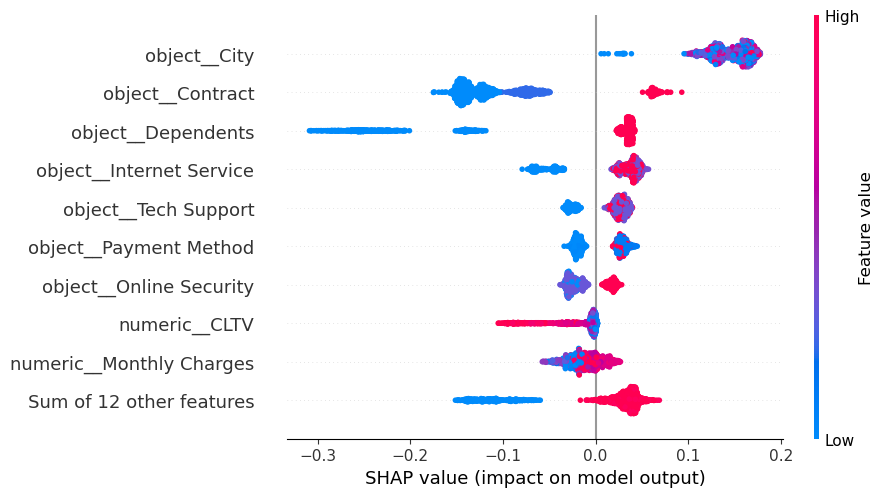

XGBClassifier


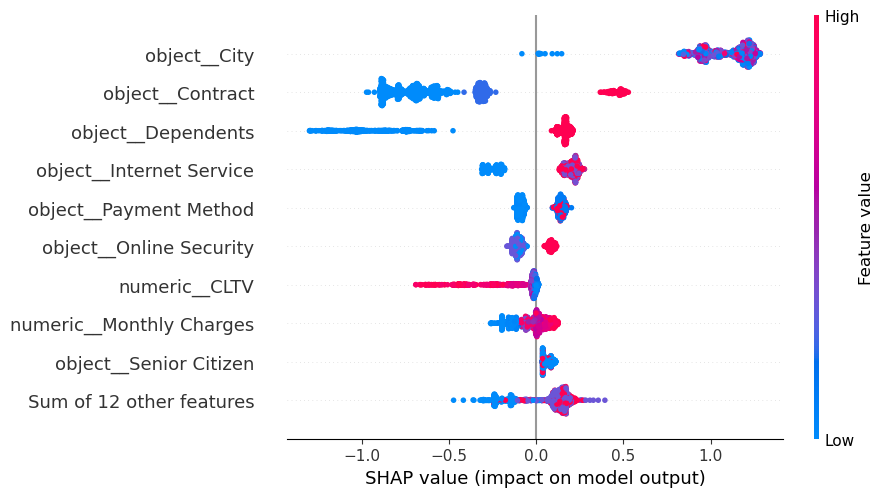

LGBMClassifier


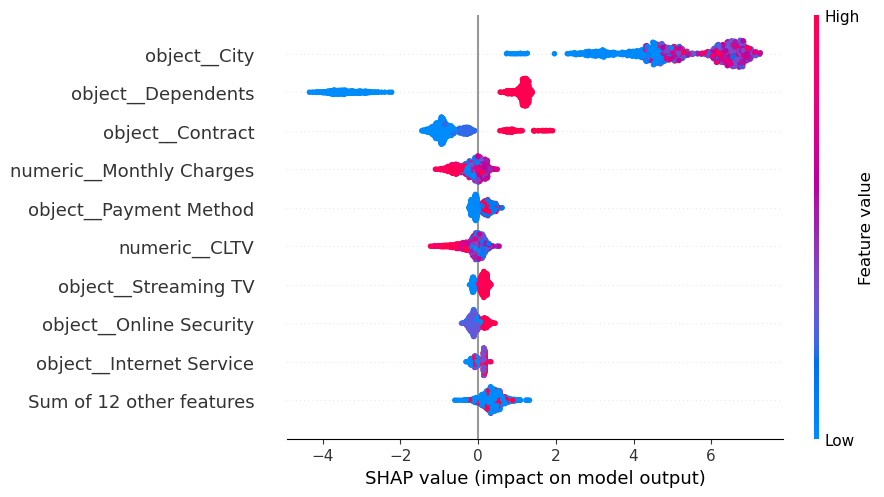

GradientBoostingClassifier


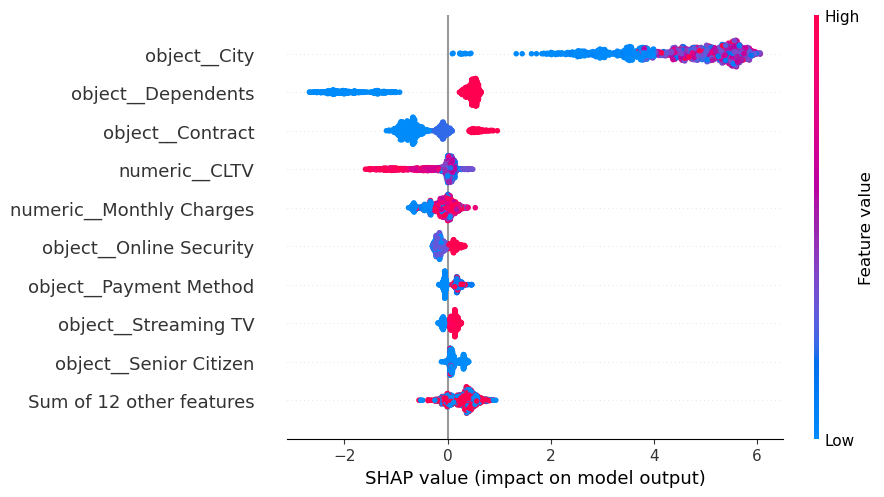

In [9]:
shap_values_tenure_sm = {}
for m in trained_models_sm:
    shap_diagnostics(m.model, X_test_sm, shap_values_tenure_sm)

RandomForestClassifier


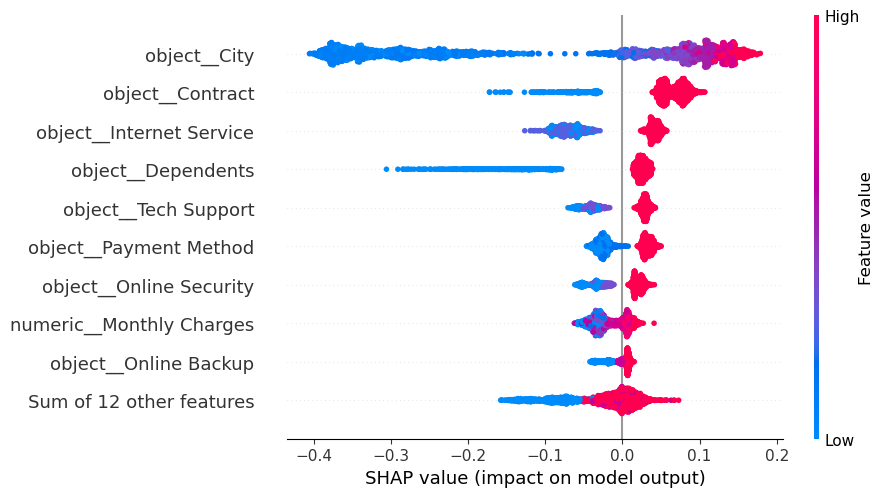

XGBClassifier


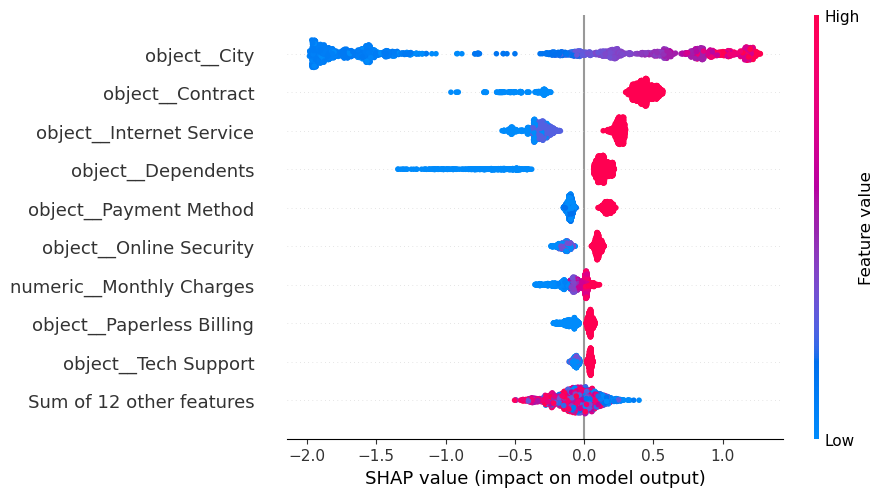

LGBMClassifier


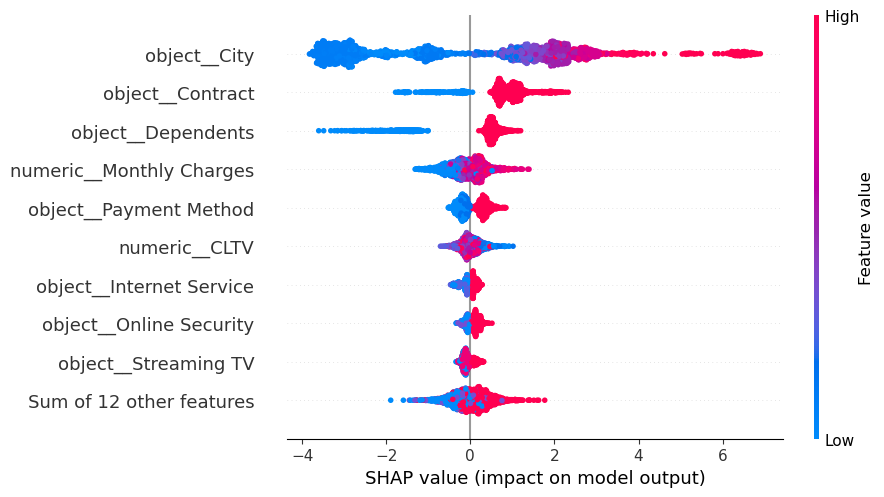

GradientBoostingClassifier


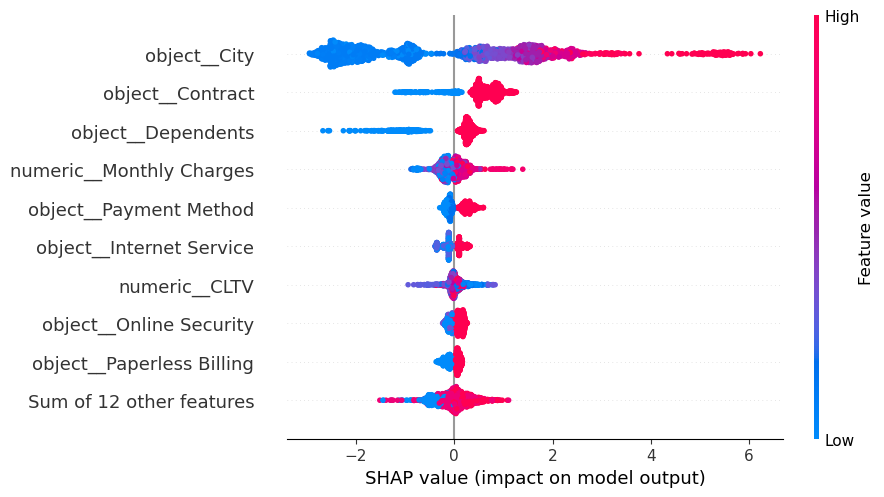

In [10]:
shap_values_tenure_ml = {}
for m in trained_models_ml:
    shap_diagnostics(m.model, X_test_ml, shap_values_tenure_ml)

### 1.2 City

In [11]:
cities = ['Top_3','Top_3_to_15', 'Top_15_and_above']

test_cat_1 = ['Top_15_and_above']
test_cat_2 = ['Top_3']
split_criteria = ['City']
blacklist = cities + ['Latitude','Longitude'] + split_criteria

X_train_15, X_test_15, y_train_15, y_test_15 = preprocess_shift_categories_da(df_collection['City'],test_cat_1, blacklist)
X_train_3, X_test_3, y_train_3, y_test_3 = preprocess_shift_categories_da(df_collection['City'],test_cat_2, blacklist)

In [12]:
trained_models_t3 = train_model(model_list, X_train_15, X_test_15, y_train_15, y_test_15, 'Top_3')


Testing DecisionTree/RF on Top_3:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      4300
           1       0.55      0.77      0.64      1540

    accuracy                           0.77      5840
   macro avg       0.72      0.77      0.74      5840
weighted avg       0.81      0.77      0.78      5840


Testing XGBoost on Top_3:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.92      0.71      0.80      4300
           1       0.50      0.82      0.62      1540

    accuracy                           0.74      5840
   macro avg       0.71      0.76      0.71      5840
weighted avg       0.81      0.74      0.75      5840

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 329, number of negative: 874
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of t

In [13]:
trained_models_above_t15 = train_model(model_list, X_train_3, X_test_3, y_train_3, y_test_3, 'Top_15_and_above')


Testing DecisionTree/RF on Top_15_and_above:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.89      0.77      0.83       398
           1       0.59      0.77      0.67       169

    accuracy                           0.77       567
   macro avg       0.74      0.77      0.75       567
weighted avg       0.80      0.77      0.78       567


Testing XGBoost on Top_15_and_above:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.90      0.75      0.82       398
           1       0.58      0.80      0.67       169

    accuracy                           0.77       567
   macro avg       0.74      0.78      0.75       567
weighted avg       0.81      0.77      0.78       567

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1700, number of negative: 4776
[LightGBM] [Info] Auto-choosing row-wise multi-thre

### SHAP Diagnostics

RandomForestClassifier


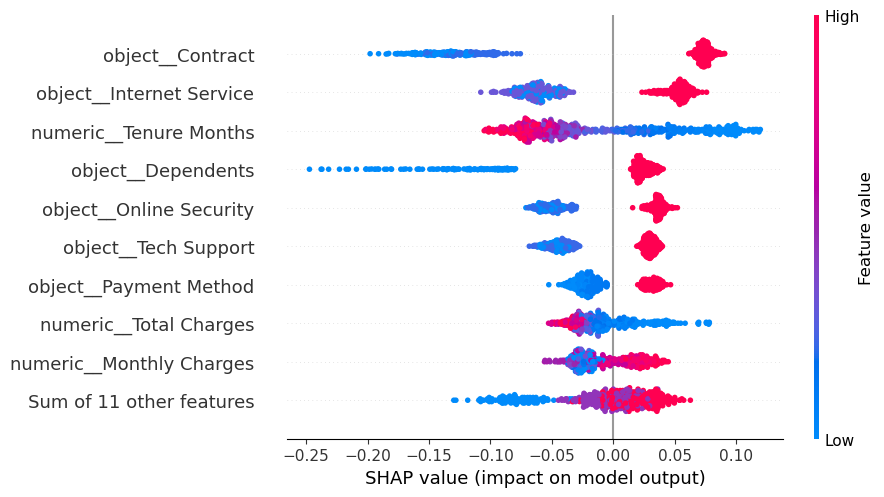

XGBClassifier


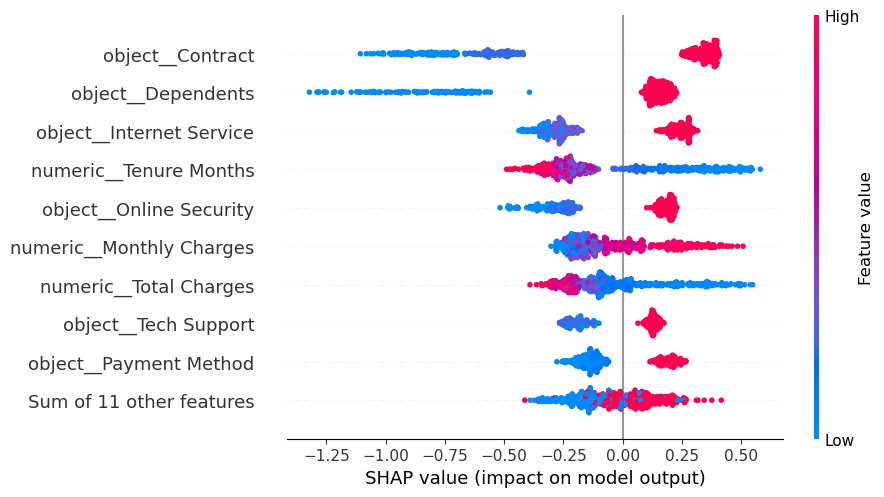

LGBMClassifier


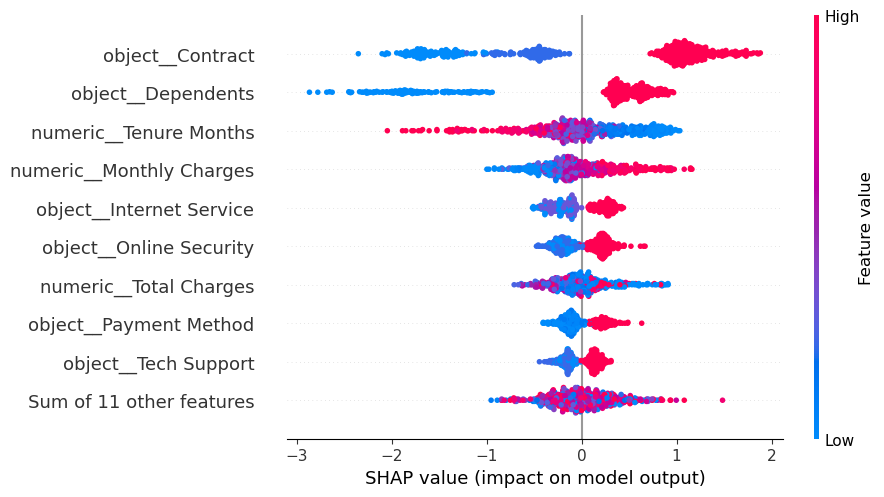

GradientBoostingClassifier


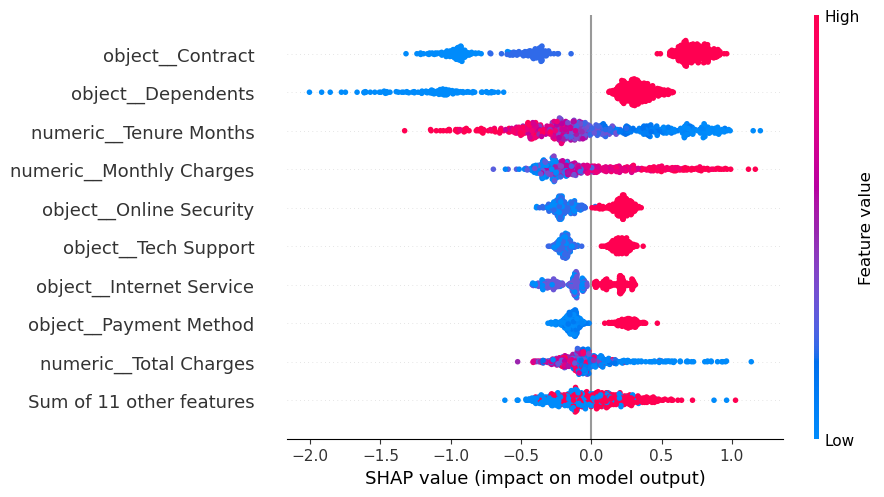

In [14]:
shap_values_city_t3 = {}
for m in trained_models_t3:
    shap_diagnostics(m.model, X_test_3, shap_values_city_t3)

RandomForestClassifier


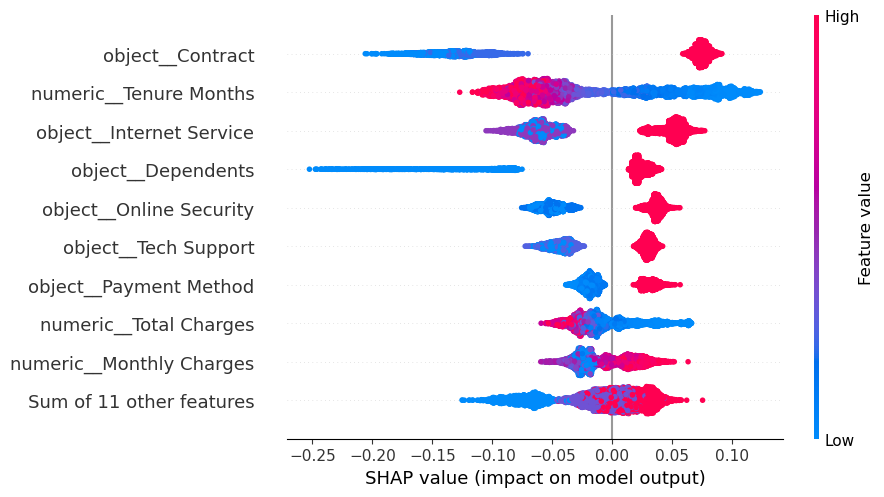

XGBClassifier


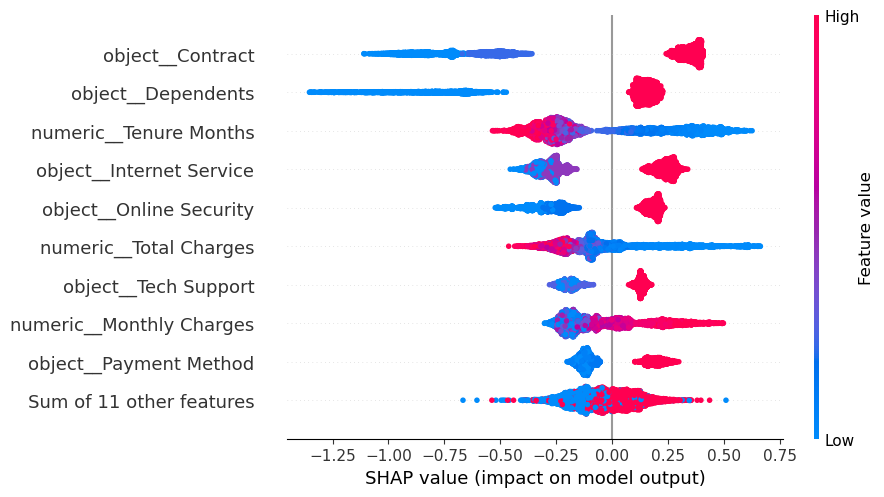

LGBMClassifier


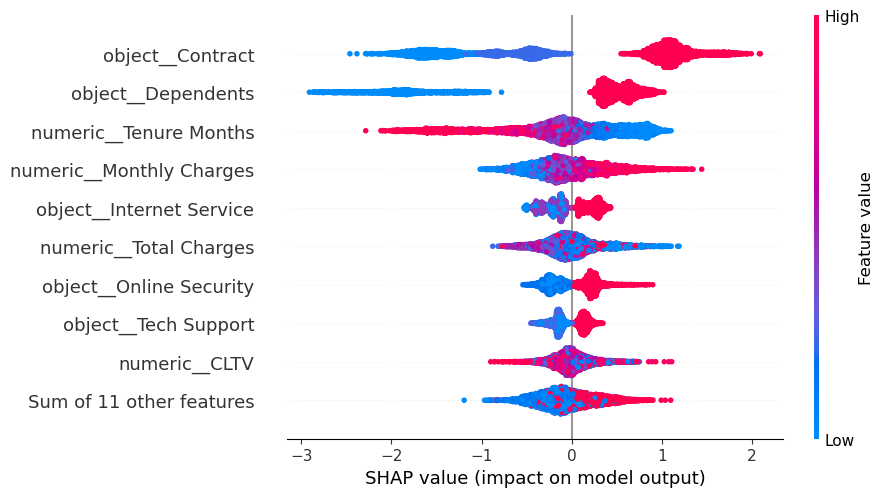

GradientBoostingClassifier


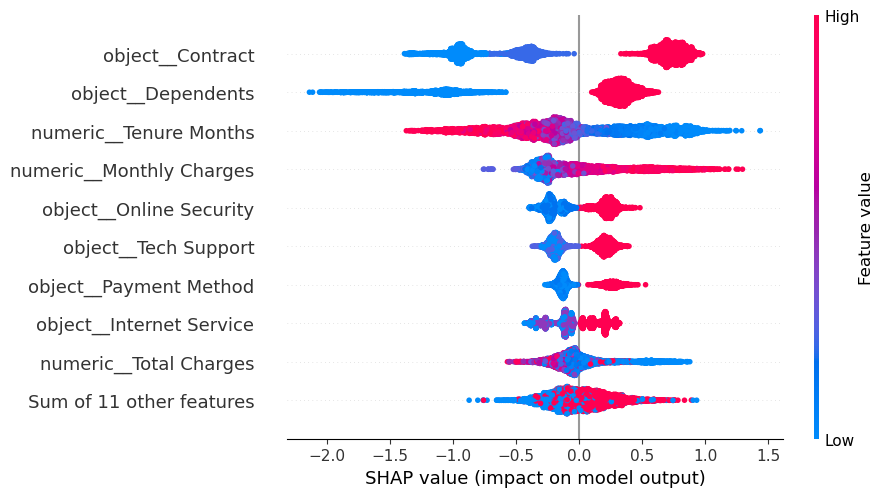

In [15]:
shap_values_city_above_t15 = {}
for m in trained_models_above_t15:
    shap_diagnostics(m.model, X_test_15, shap_values_city_above_t15)

### 1.3 Family Status

In [16]:
test_cat_1 = ['Male_No_No', 'Female_No_No']
test_cat_2 = ['Female_No_Yes','Male_No_Yes']
test_cat_3 = ['Male_Yes_Yes', 'Female_Yes_Yes']

split_criteria = ['Gender','Partner','Dependents']

blacklist = split_criteria + list(df_collection['Status'].keys())

X_train_s1, X_test_s1, y_train_s1, y_test_s1 =\
             preprocess_shift_categories_da(df_collection['Status'],test_cat_1, blacklist)
X_train_s2, X_test_s2, y_train_s2, y_test_s2 =\
             preprocess_shift_categories_da(df_collection['Status'],test_cat_2, blacklist)
X_train_s3, X_test_s3, y_train_s3, y_test_s3 =\
             preprocess_shift_categories_da(df_collection['Status'],test_cat_3, blacklist)

In [17]:
trained_models_s1 = train_model(model_list, X_train_s1, X_test_s1, y_train_s1, y_test_s1, 'Single People without Children')


Testing DecisionTree/RF on Single People without Children:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.75      0.73      0.74      2189
           1       0.51      0.54      0.53      1150

    accuracy                           0.66      3339
   macro avg       0.63      0.63      0.63      3339
weighted avg       0.67      0.66      0.67      3339


Testing XGBoost on Single People without Children:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.73      0.75      0.74      2189
           1       0.50      0.47      0.48      1150

    accuracy                           0.66      3339
   macro avg       0.62      0.61      0.61      3339
weighted avg       0.65      0.66      0.65      3339

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 719, number of negative: 2985
[LightGBM] [Info] Auto-c

In [18]:
trained_models_s2 = train_model(model_list, X_train_s2, X_test_s2, y_train_s2, y_test_s2, 'Single Moms/Dads')


Testing DecisionTree/RF on Single Moms/Dads:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.94      0.72      0.81       252
           1       0.35      0.76      0.48        50

    accuracy                           0.73       302
   macro avg       0.64      0.74      0.65       302
weighted avg       0.84      0.73      0.76       302


Testing XGBoost on Single Moms/Dads:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.93      0.73      0.82       252
           1       0.36      0.74      0.48        50

    accuracy                           0.74       302
   macro avg       0.65      0.74      0.65       302
weighted avg       0.84      0.74      0.77       302

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1819, number of negative: 4922
[LightGBM] [Info] Auto-choosing col-wise multi-thre

In [19]:
trained_models_s3 = train_model(model_list, X_train_s3, X_test_s3, y_train_s3, y_test_s3, 'Family People')


Testing DecisionTree/RF on Family People:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      1269
           1       0.13      0.52      0.21        56

    accuracy                           0.84      1325
   macro avg       0.55      0.68      0.56      1325
weighted avg       0.94      0.84      0.88      1325


Testing XGBoost on Family People:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.80      0.88      1269
           1       0.12      0.61      0.20        56

    accuracy                           0.79      1325
   macro avg       0.55      0.70      0.54      1325
weighted avg       0.94      0.79      0.85      1325

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1813, number of negative: 3905
[LightGBM] [Info] Auto-choosing row-wise multi-threading,

### SHAP Diagnostics

RandomForestClassifier


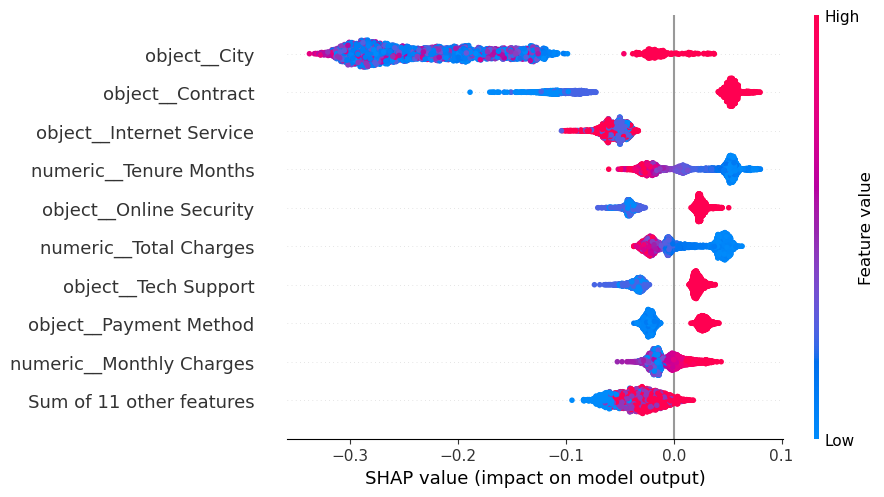

XGBClassifier


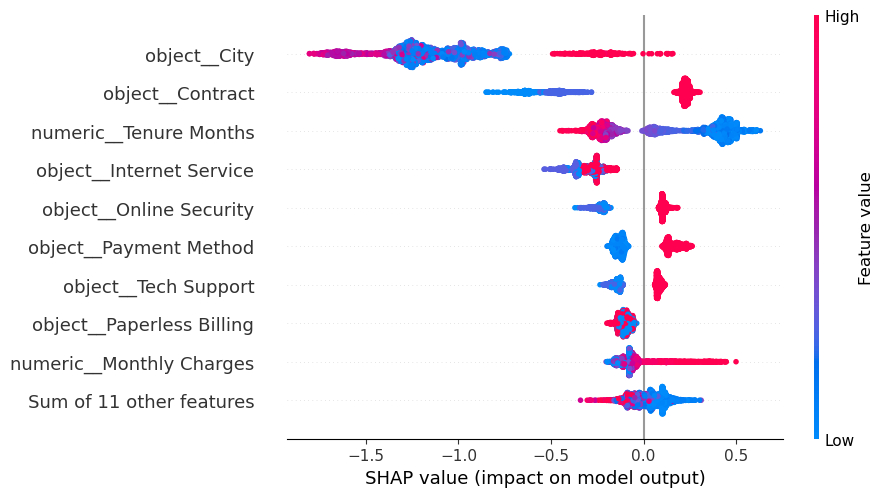

LGBMClassifier


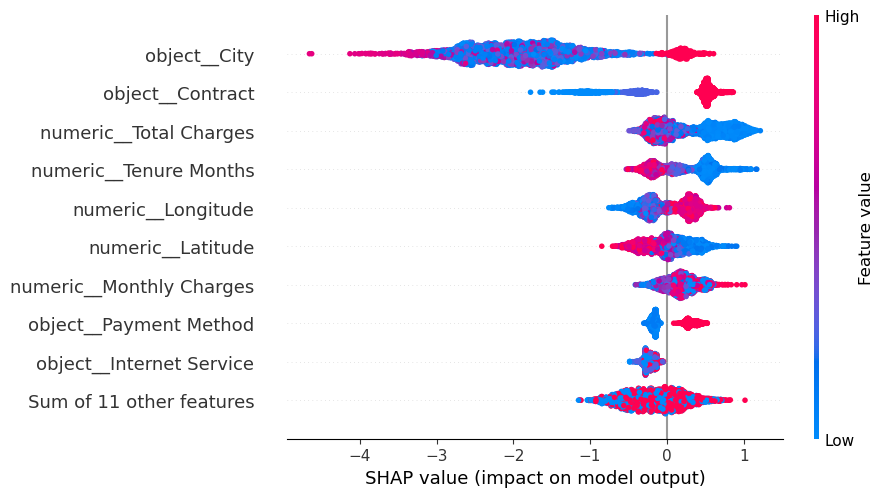

GradientBoostingClassifier


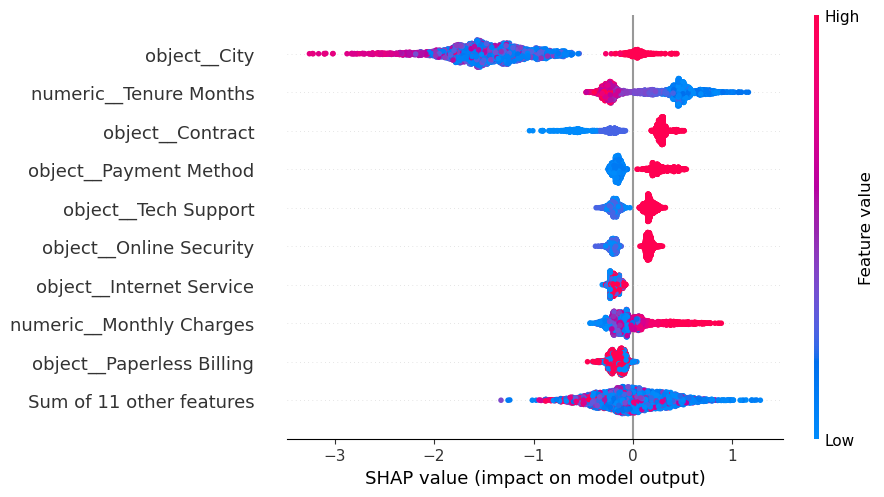

In [20]:
shap_values_s1 = {}
for m in trained_models_s1:
    shap_diagnostics(m.model, X_test_s1, shap_values_s1)

RandomForestClassifier


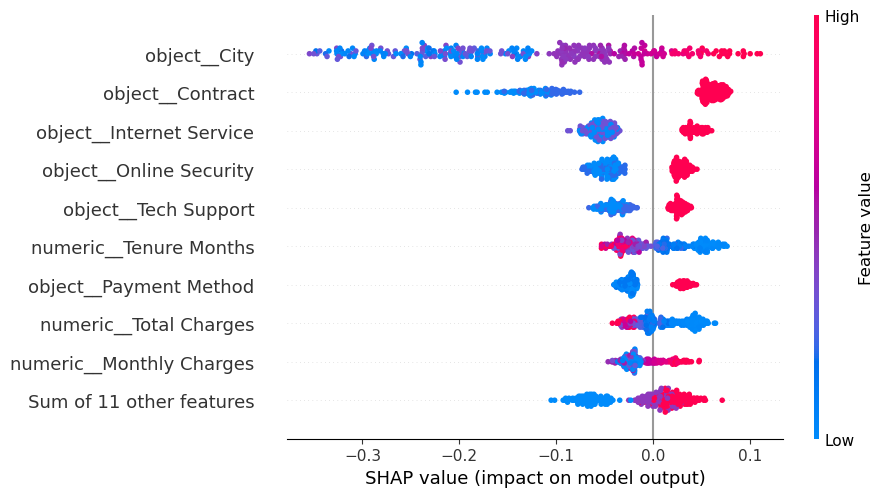

XGBClassifier


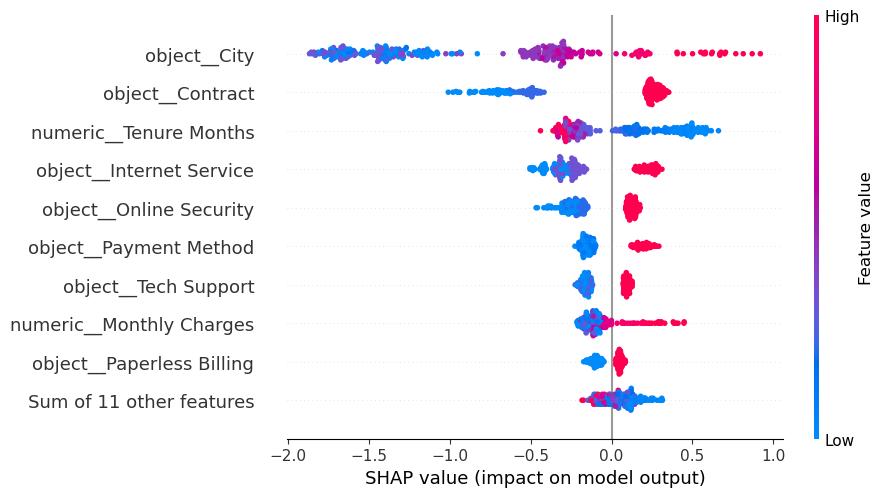

LGBMClassifier


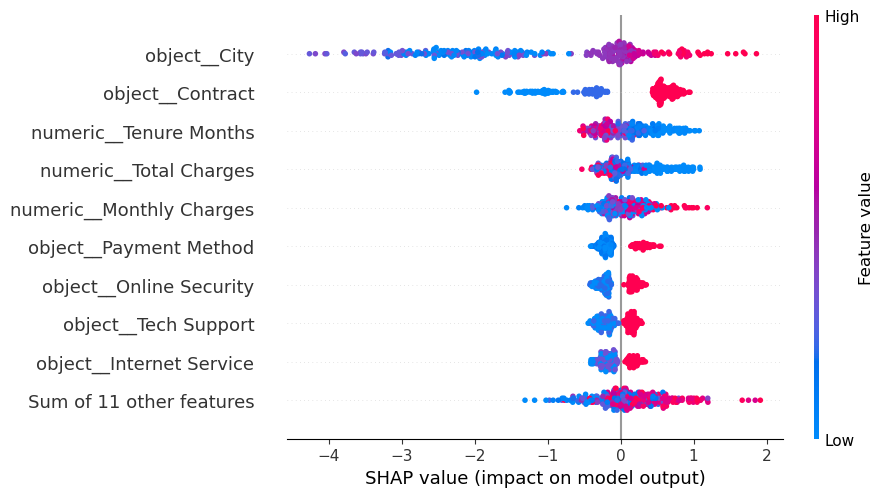

GradientBoostingClassifier


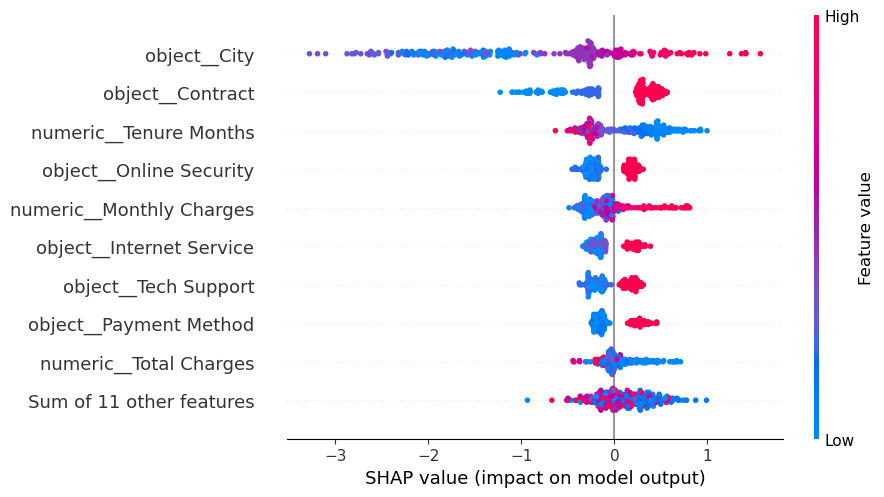

In [21]:
shap_values_s2 = {}
for m in trained_models_s2:
    shap_diagnostics(m.model, X_test_s2, shap_values_s2)

RandomForestClassifier


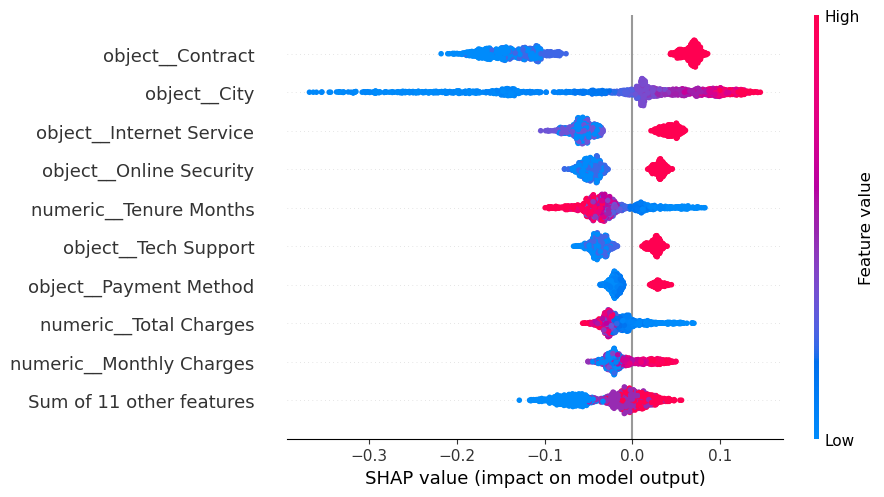

XGBClassifier


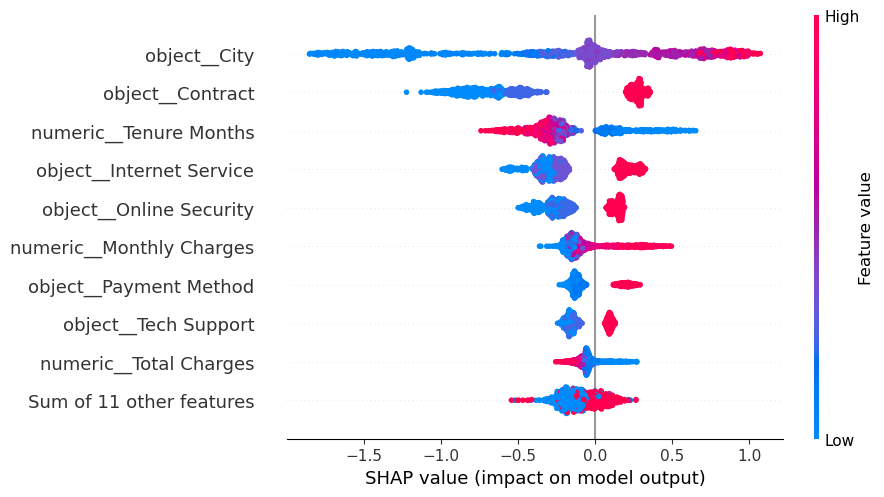

LGBMClassifier


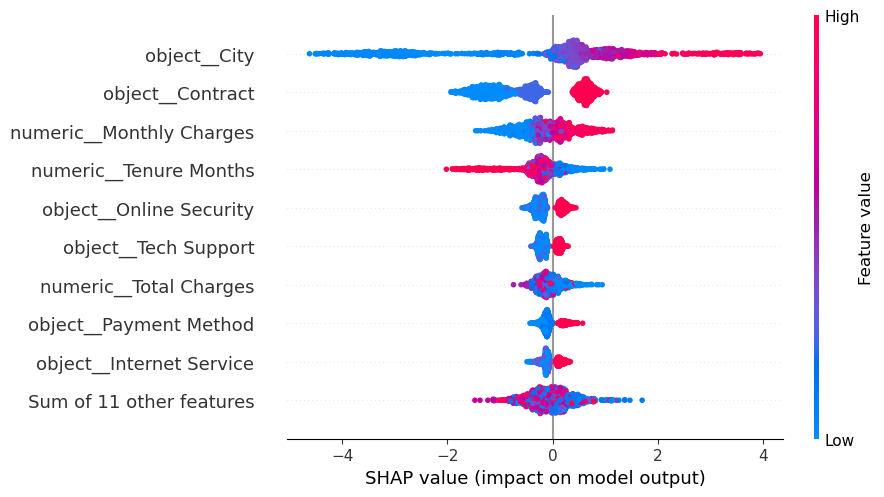

GradientBoostingClassifier


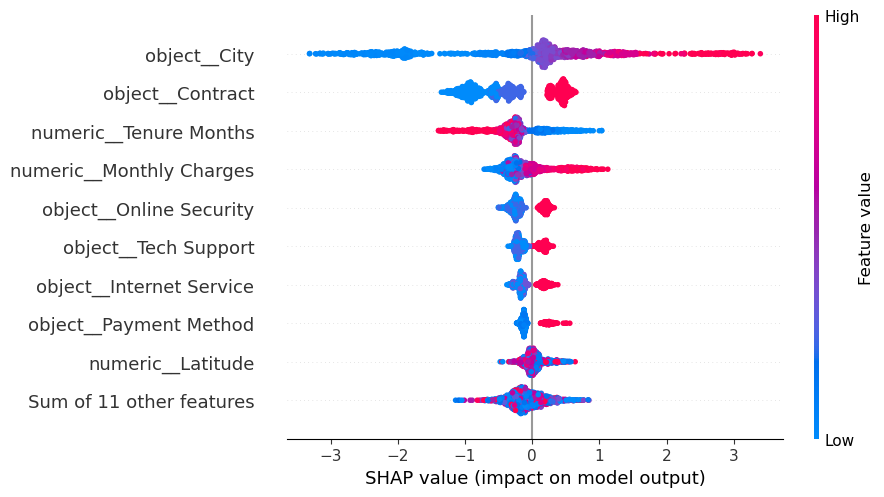

In [22]:
shap_values_s3 = {}
for m in trained_models_s3:
    shap_diagnostics(m.model, X_test_s3, shap_values_s3)

# 2. Subpopulation Analysis 

### 2.1 Tenure Cohort

In [23]:
X_train_sm, X_test_sm, y_train_sm, y_test_sm = preprocess_shift_categories_sa(X,y,df_collection['Tenure'],['Long'])
X_train_ml, X_test_ml, y_train_ml, y_test_ml = preprocess_shift_categories_sa(X,y,df_collection['Tenure'],['Short'])

In [24]:
trained_models_sm = train_model(model_list, X_train_sm, X_test_sm, y_train_sm, y_test_sm, 'Long Tenure')


Testing DecisionTree/RF on Long Tenure:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1314
           1       0.44      0.54      0.49        93

    accuracy                           0.92      1407
   macro avg       0.70      0.74      0.72      1407
weighted avg       0.93      0.92      0.93      1407


Testing XGBoost on Long Tenure:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1314
           1       0.42      0.54      0.47        93

    accuracy                           0.92      1407
   macro avg       0.69      0.74      0.71      1407
weighted avg       0.93      0.92      0.92      1407

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1402, number of negative: 3880
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the

In [25]:
trained_models_ml = train_model(model_list, X_train_ml, X_test_ml, y_train_ml, y_test_ml, 'Short Tenure')


Testing DecisionTree/RF on Short Tenure:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.79      0.69      0.74      1149
           1       0.70      0.80      0.75      1037

    accuracy                           0.74      2186
   macro avg       0.75      0.74      0.74      2186
weighted avg       0.75      0.74      0.74      2186


Testing XGBoost on Short Tenure:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.80      0.65      0.72      1149
           1       0.68      0.82      0.74      1037

    accuracy                           0.73      2186
   macro avg       0.74      0.73      0.73      2186
weighted avg       0.74      0.73      0.73      2186

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1402, number of negative: 3880
[LightGBM] [Info] Auto-choosing row-wise multi-threading, t

### SHAP Diagnostics

RandomForestClassifier


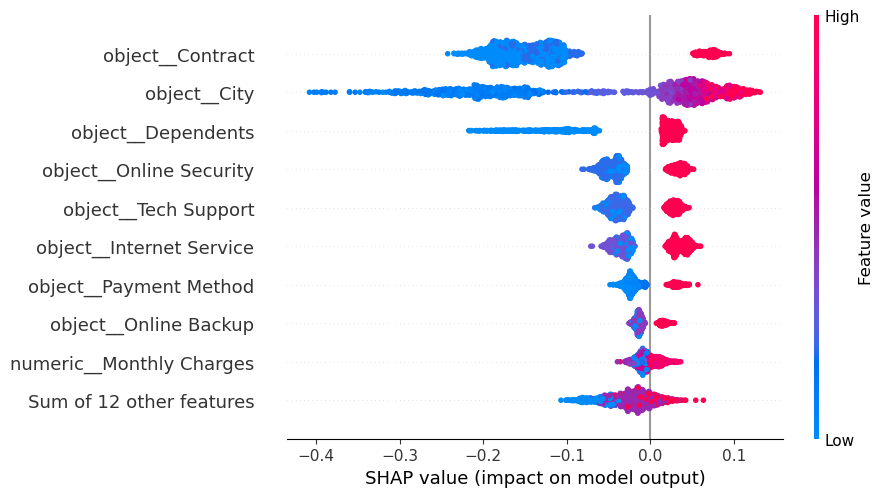

XGBClassifier


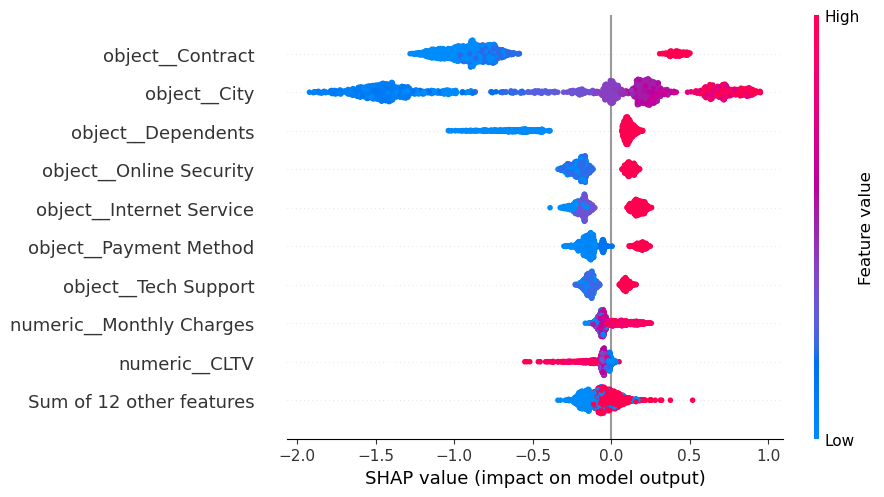

LGBMClassifier


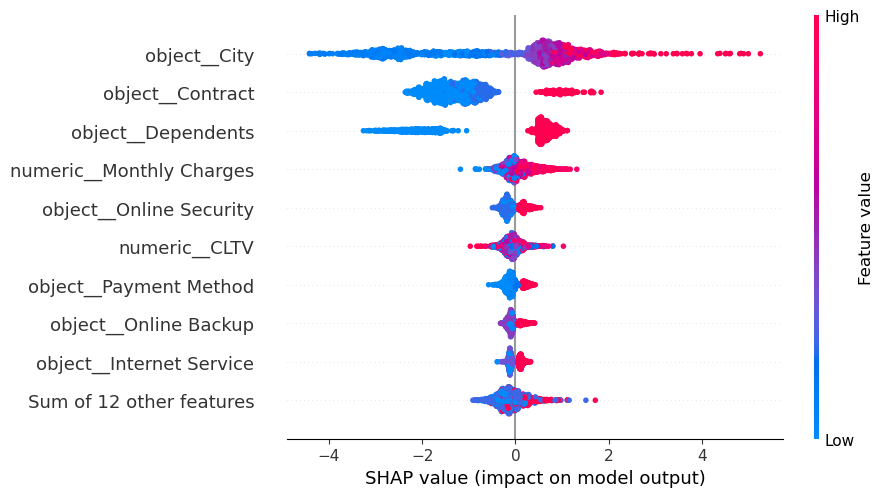

GradientBoostingClassifier


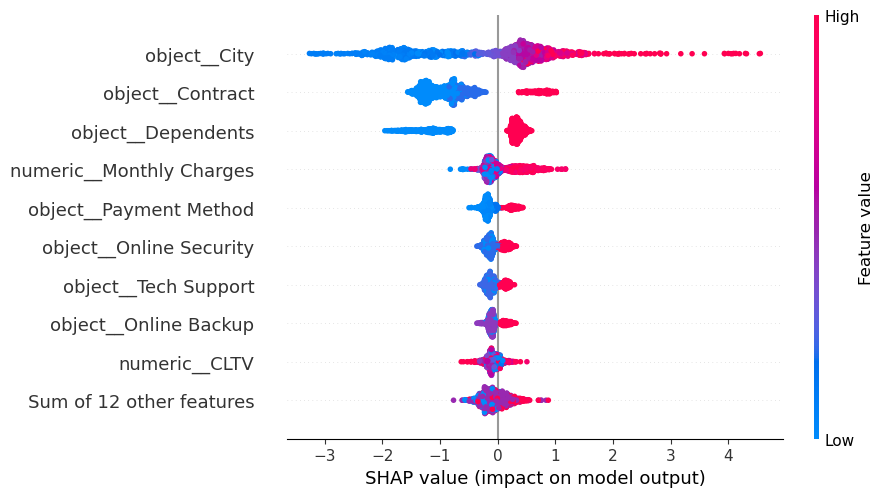

In [26]:
shap_values_tenure_sm_sub = {}
for m in trained_models_sm:
    shap_diagnostics(m.model, X_test_sm, shap_values_tenure_sm_sub)

RandomForestClassifier


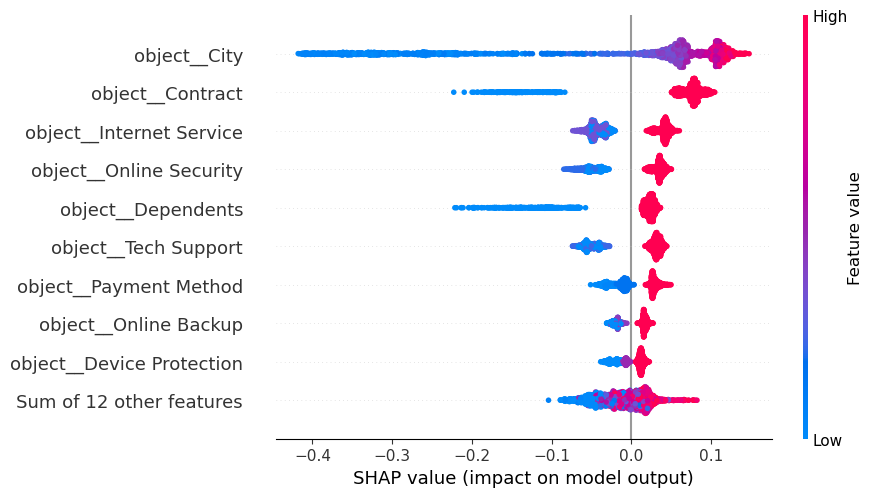

XGBClassifier


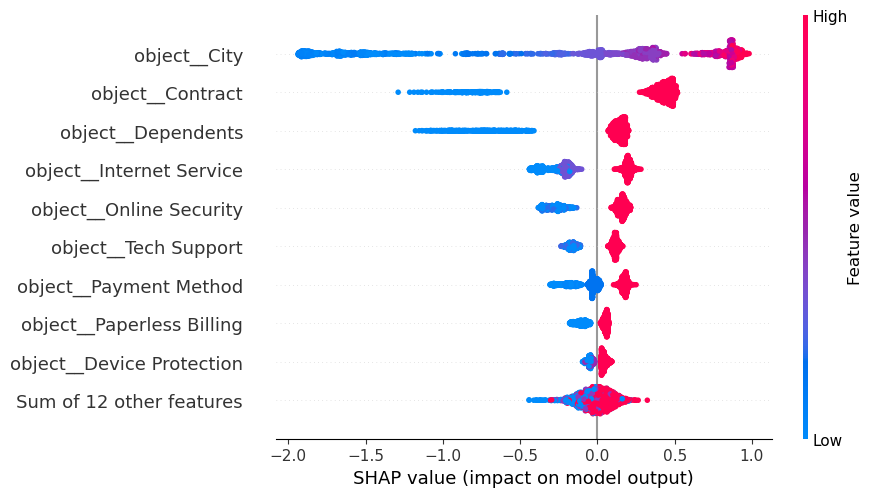

LGBMClassifier


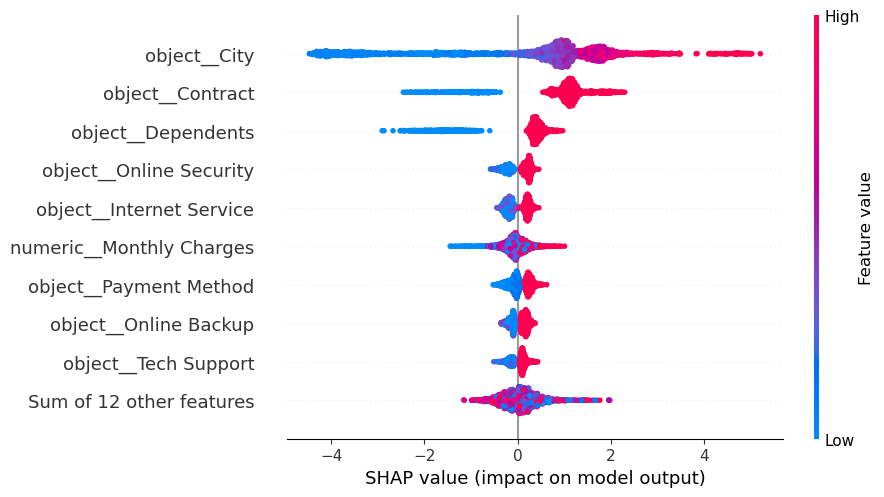

GradientBoostingClassifier


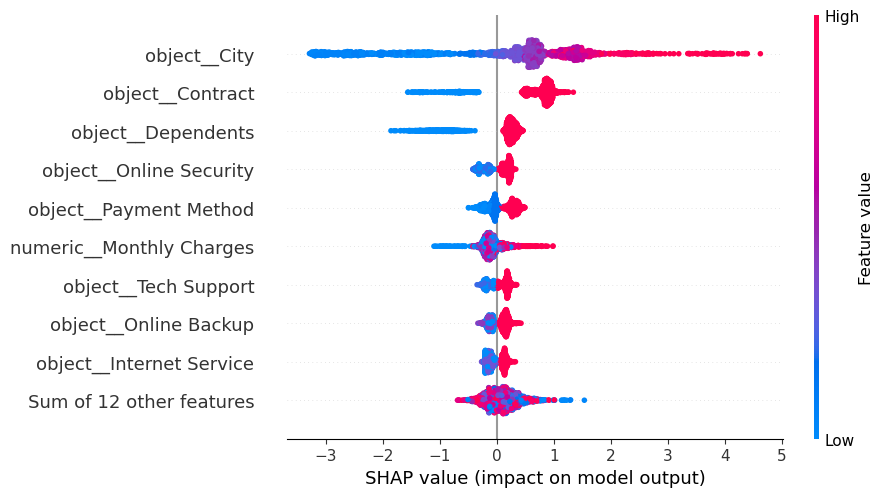

In [27]:
shap_values_tenure_ml_sub = {}
for m in trained_models_ml:
    shap_diagnostics(m.model, X_test_ml, shap_values_tenure_ml_sub)

### 2.2 City

In [28]:
cities = ['Top_3','Top_3_to_15', 'Top_15_and_above']

test_cat_1 = ['Top_15_and_above']
test_cat_2 = ['Top_3']
split_criteria = ['City']
blacklist = cities + ['Latitude','Longitude'] + split_criteria

X_train_15, X_test_15, y_train_15, y_test_15 = preprocess_shift_categories_sa(X,y,df_collection['City'],test_cat_1, blacklist)
X_train_3, X_test_3, y_train_3, y_test_3 = preprocess_shift_categories_sa(X,y,df_collection['City'],test_cat_2, blacklist)

In [29]:
trained_models_t3 = train_model(model_list, X_train_15, X_test_15, y_train_15, y_test_15, 'Top_3')


Testing DecisionTree/RF on Top_3:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.93      0.77      0.84      4300
           1       0.56      0.83      0.67      1540

    accuracy                           0.79      5840
   macro avg       0.75      0.80      0.76      5840
weighted avg       0.83      0.79      0.80      5840


Testing XGBoost on Top_3:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.93      0.75      0.83      4300
           1       0.55      0.84      0.66      1540

    accuracy                           0.77      5840
   macro avg       0.74      0.80      0.75      5840
weighted avg       0.83      0.77      0.79      5840

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1402, number of negative: 3880
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of

In [30]:
trained_models_above_t15 = train_model(model_list, X_train_3, X_test_3, y_train_3, y_test_3, 'Top_15_and_above')


Testing DecisionTree/RF on Top_15_and_above:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.90      0.78      0.83       398
           1       0.60      0.80      0.69       169

    accuracy                           0.78       567
   macro avg       0.75      0.79      0.76       567
weighted avg       0.81      0.78      0.79       567


Testing XGBoost on Top_15_and_above:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       398
           1       0.61      0.82      0.70       169

    accuracy                           0.79       567
   macro avg       0.76      0.80      0.77       567
weighted avg       0.82      0.79      0.79       567

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1402, number of negative: 3880
[LightGBM] [Info] Auto-choosing row-wise multi-thre

### SHAP Diagnostics

RandomForestClassifier


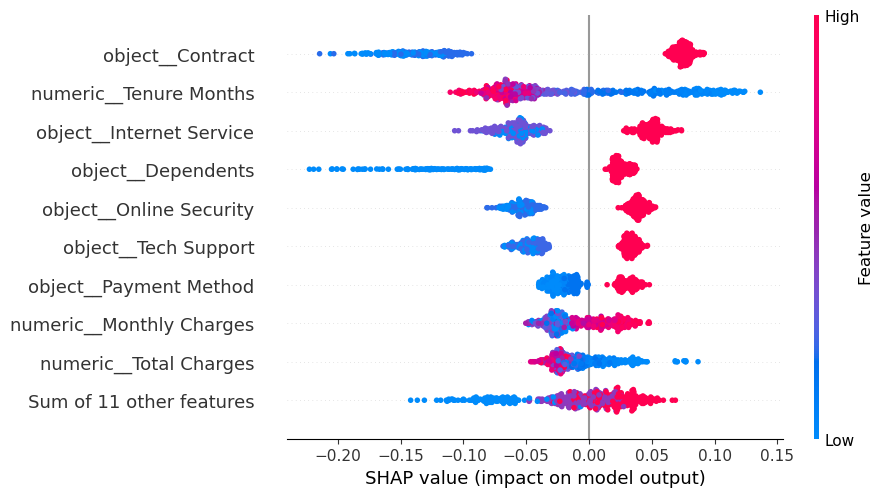

XGBClassifier


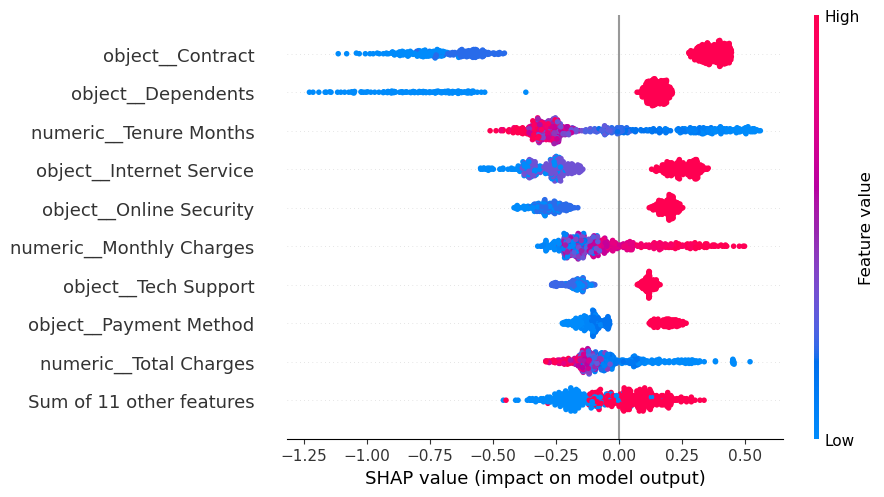

LGBMClassifier


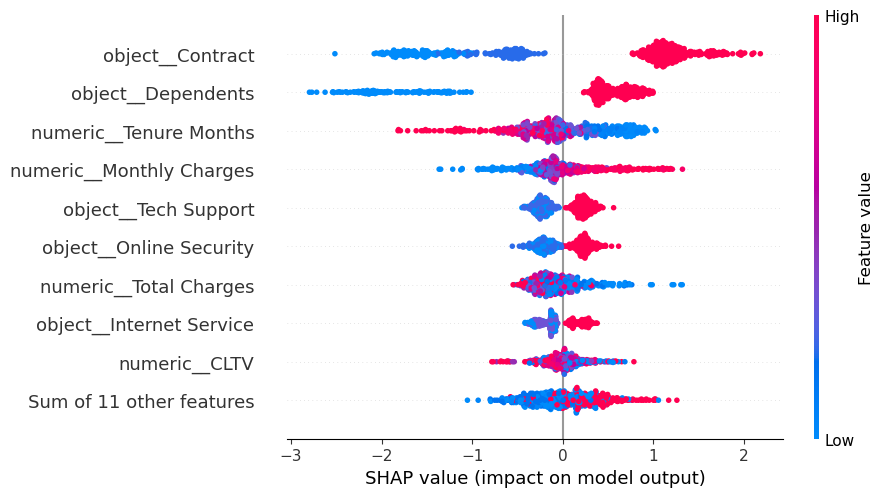

GradientBoostingClassifier


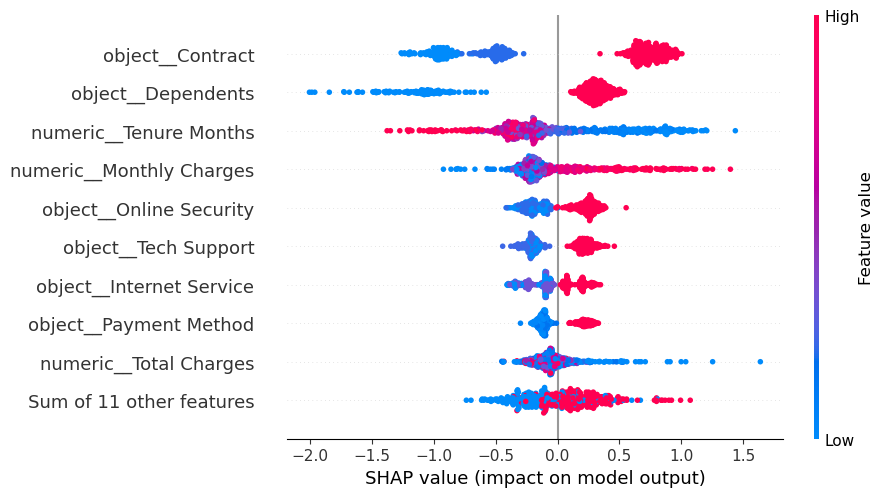

In [31]:
shap_values_city_t3_sub = {}
for m in trained_models_t3:
    shap_diagnostics(m.model, X_test_3, shap_values_city_t3_sub)

RandomForestClassifier


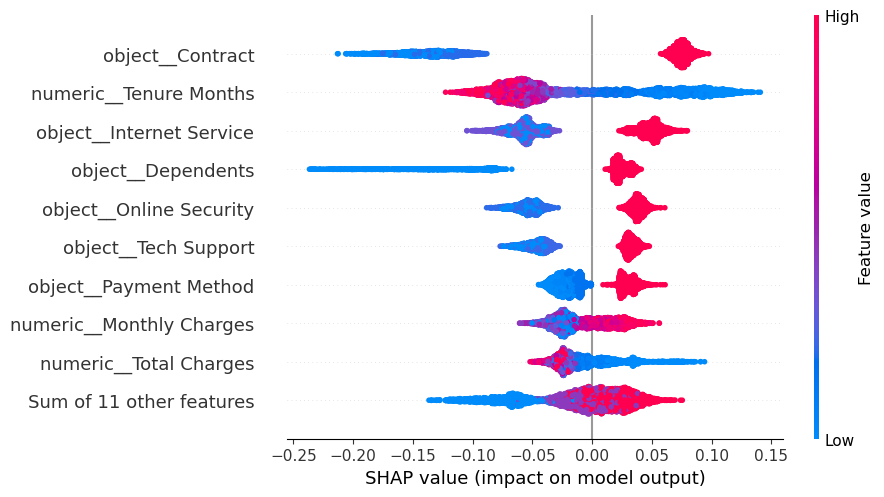

XGBClassifier


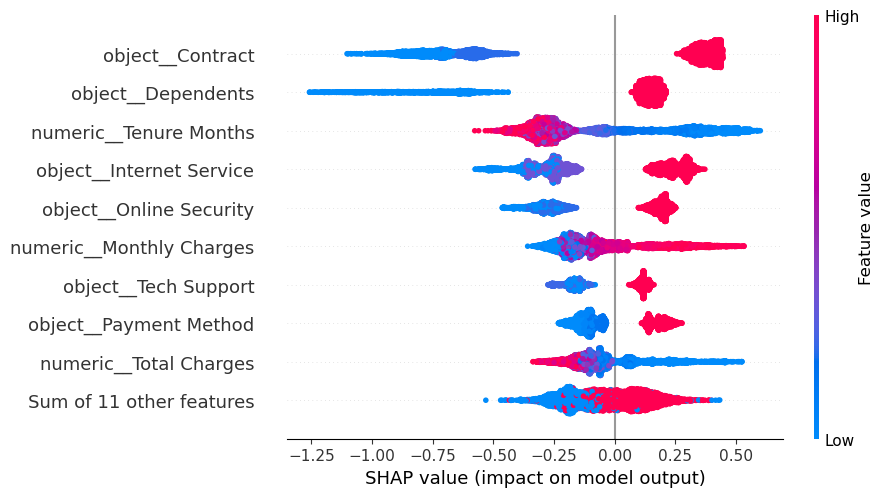

LGBMClassifier


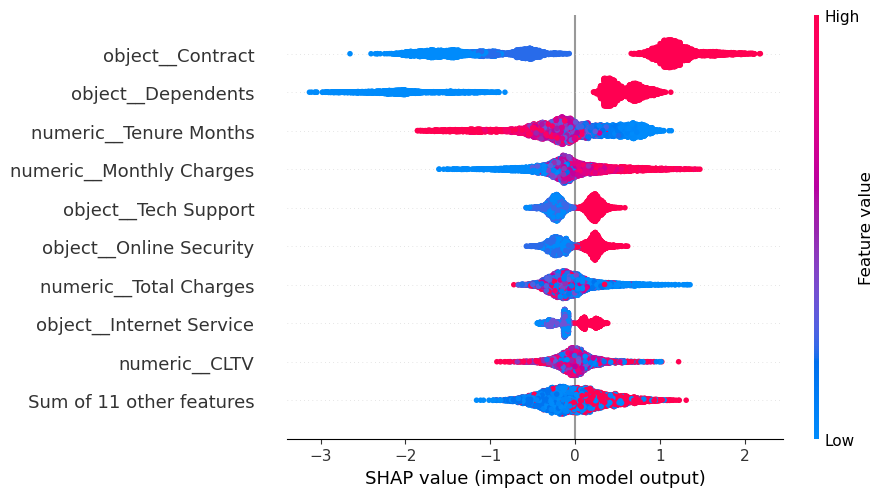

GradientBoostingClassifier


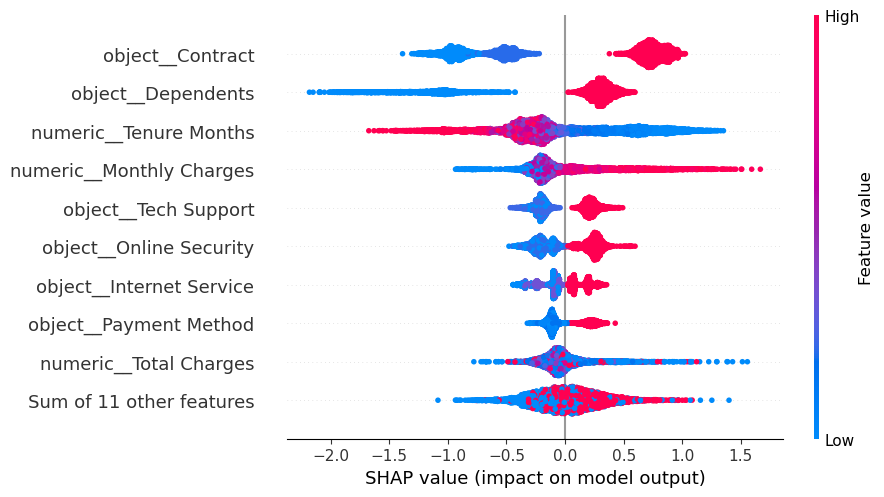

In [32]:
shap_values_city_above_t15_sub = {}
for m in trained_models_above_t15:
    shap_diagnostics(m.model, X_test_15, shap_values_city_above_t15_sub)

### 2.3 Family Status

In [33]:
test_cat_1 = ['Male_No_No', 'Female_No_No']
test_cat_2 = ['Female_No_Yes','Male_No_Yes']
test_cat_3 = ['Male_Yes_Yes', 'Female_Yes_Yes']

split_criteria = ['Gender','Partner','Dependents']

blacklist = split_criteria + list(df_collection['Status'].keys())

X_train_s1, X_test_s1, y_train_s1, y_test_s1 =\
             preprocess_shift_categories_sa(X,y,df_collection['Status'],test_cat_1, blacklist)
X_train_s2, X_test_s2, y_train_s2, y_test_s2 =\
             preprocess_shift_categories_sa(X,y,df_collection['Status'],test_cat_2, blacklist)
X_train_s3, X_test_s3, y_train_s3, y_test_s3 =\
             preprocess_shift_categories_sa(X,y,df_collection['Status'],test_cat_3, blacklist)

In [34]:
trained_models_s1 = train_model(model_list, X_train_s1, X_test_s1, y_train_s1, y_test_s1, 'Single People without Children')


Testing DecisionTree/RF on Single People without Children:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.89      0.73      0.80      2189
           1       0.62      0.83      0.71      1150

    accuracy                           0.76      3339
   macro avg       0.75      0.78      0.75      3339
weighted avg       0.80      0.76      0.77      3339


Testing XGBoost on Single People without Children:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.88      0.71      0.79      2189
           1       0.60      0.82      0.69      1150

    accuracy                           0.75      3339
   macro avg       0.74      0.77      0.74      3339
weighted avg       0.78      0.75      0.76      3339

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1402, number of negative: 3880
[LightGBM] [Info] Auto-

In [35]:
trained_models_s2 = train_model(model_list, X_train_s2, X_test_s2, y_train_s2, y_test_s2, 'Single Moms/Dads')


Testing DecisionTree/RF on Single Moms/Dads:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.97      0.80      0.88       252
           1       0.46      0.88      0.61        50

    accuracy                           0.81       302
   macro avg       0.72      0.84      0.74       302
weighted avg       0.89      0.81      0.83       302


Testing XGBoost on Single Moms/Dads:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.96      0.78      0.86       252
           1       0.43      0.84      0.57        50

    accuracy                           0.79       302
   macro avg       0.70      0.81      0.72       302
weighted avg       0.87      0.79      0.81       302

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1402, number of negative: 3880
[LightGBM] [Info] Auto-choosing row-wise multi-thre

In [36]:
trained_models_s3 = train_model(model_list, X_train_s3, X_test_s3, y_train_s3, y_test_s3, 'Family People')


Testing DecisionTree/RF on Family People:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      1269
           1       0.20      0.70      0.32        56

    accuracy                           0.87      1325
   macro avg       0.59      0.79      0.62      1325
weighted avg       0.95      0.87      0.90      1325


Testing XGBoost on Family People:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      1269
           1       0.17      0.70      0.28        56

    accuracy                           0.85      1325
   macro avg       0.58      0.77      0.60      1325
weighted avg       0.95      0.85      0.89      1325

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1402, number of negative: 3880
[LightGBM] [Info] Auto-choosing row-wise multi-threading,

### SHAP Diagnostics

RandomForestClassifier


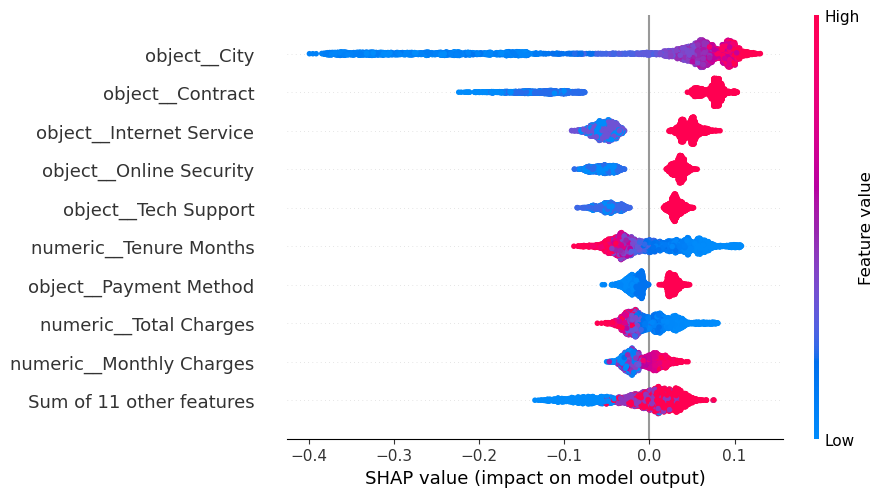

XGBClassifier


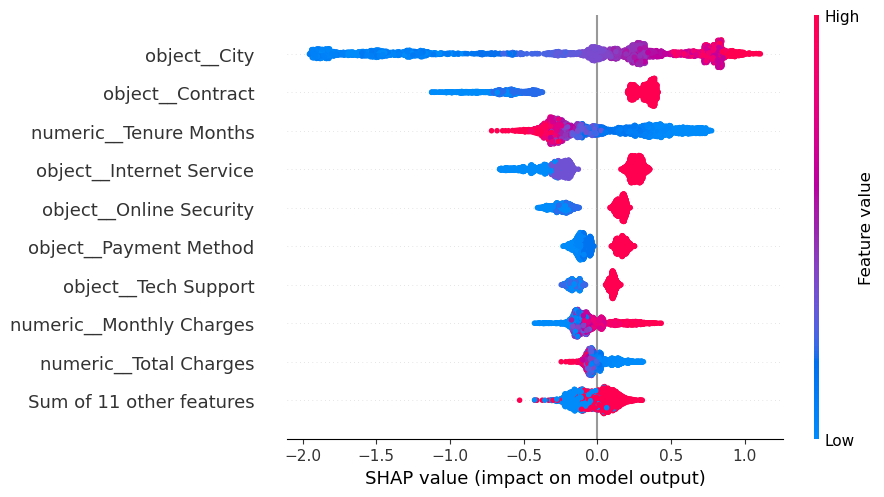

LGBMClassifier


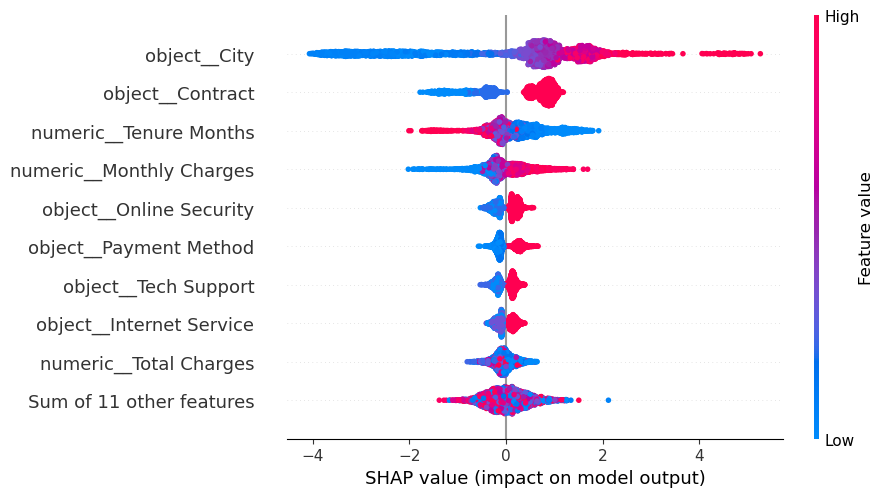

GradientBoostingClassifier


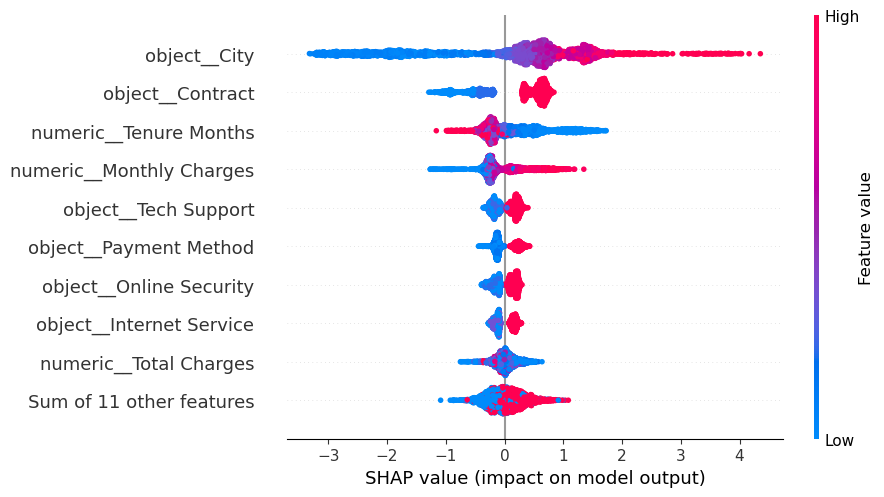

In [37]:
shap_values_s1_sub = {}
for m in trained_models_s1:
    shap_diagnostics(m.model, X_test_s1, shap_values_s1_sub)

RandomForestClassifier


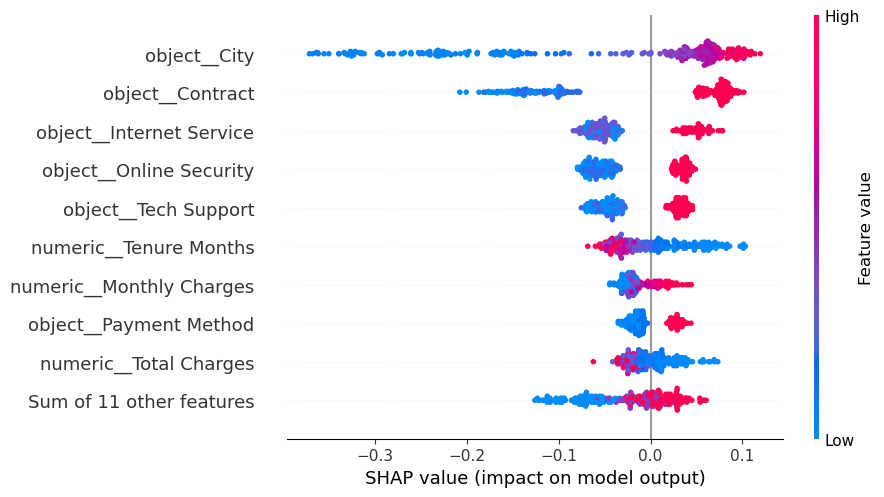

XGBClassifier


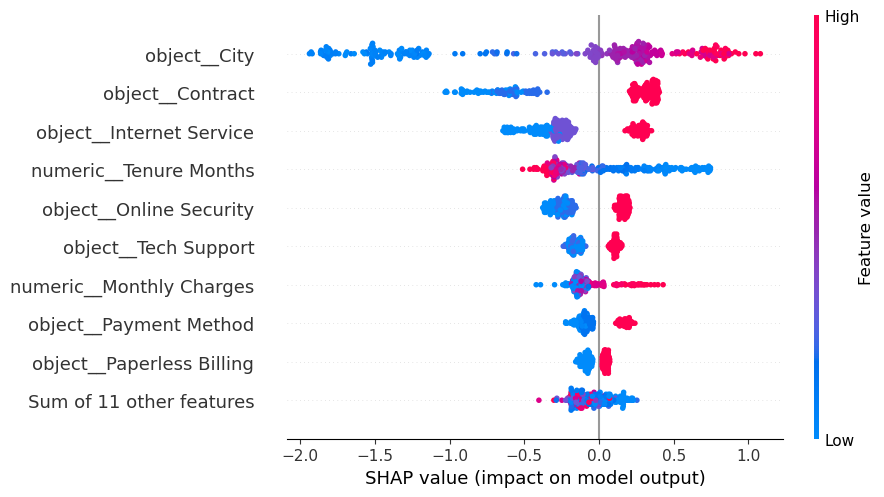

LGBMClassifier


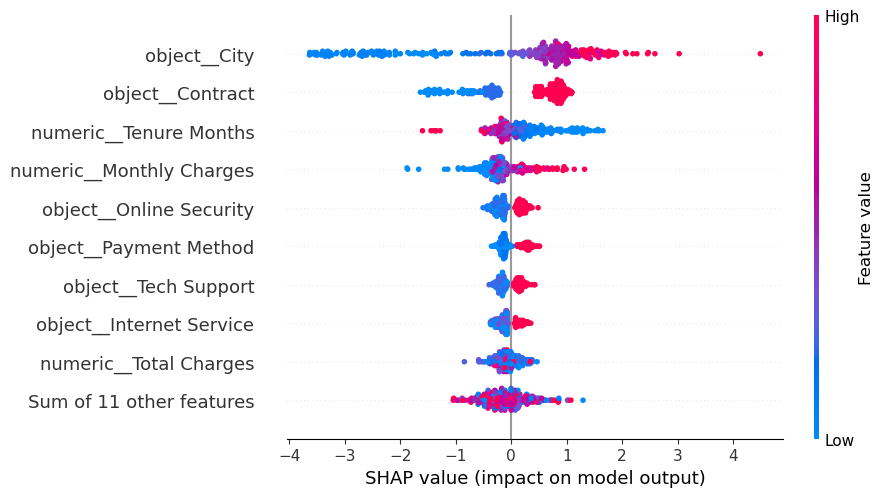

GradientBoostingClassifier


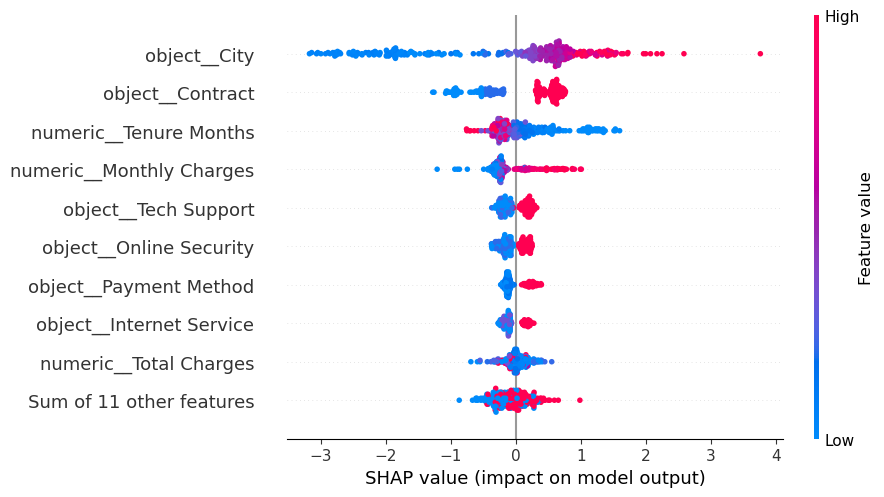

In [38]:
shap_values_s2_sub = {}
for m in trained_models_s2:
    shap_diagnostics(m.model, X_test_s2, shap_values_s2_sub)

RandomForestClassifier


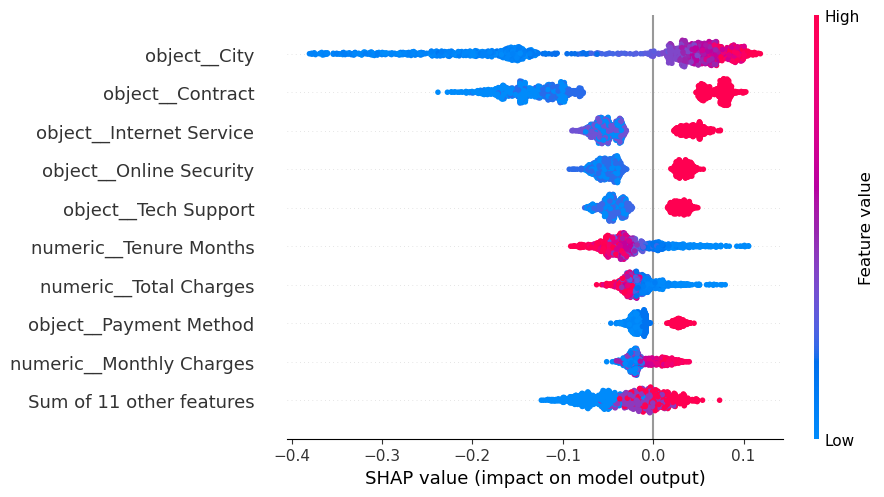

XGBClassifier


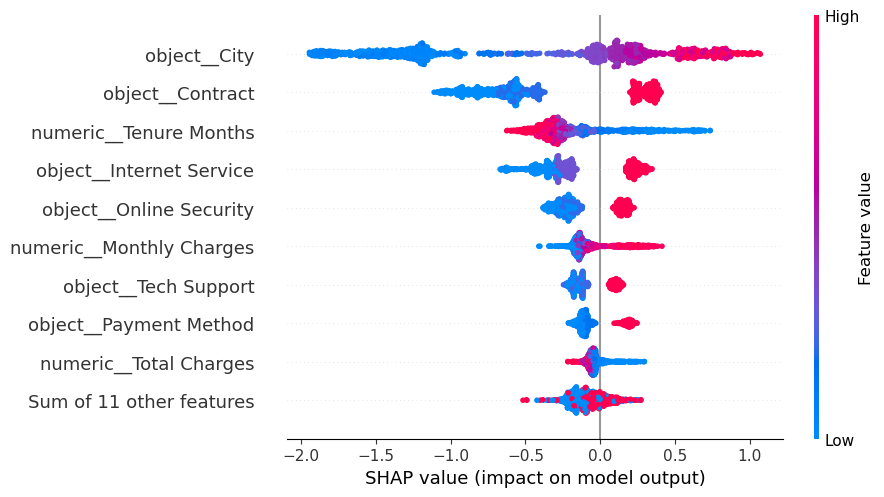

LGBMClassifier


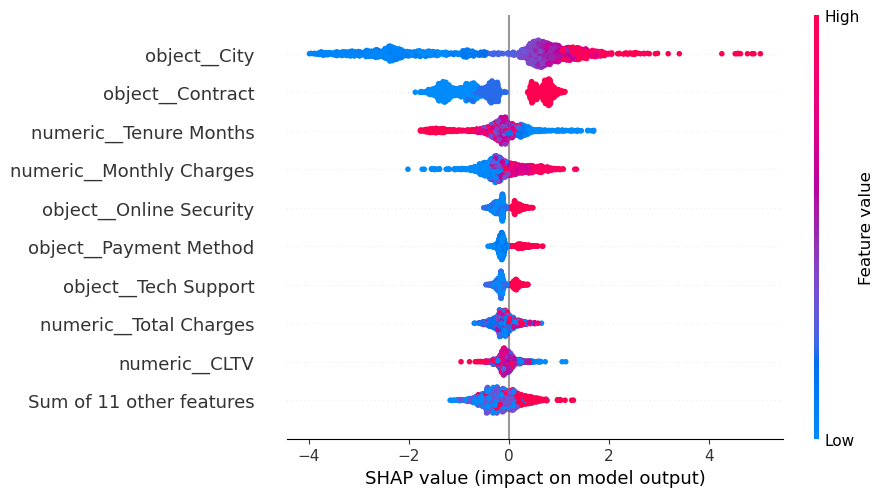

GradientBoostingClassifier


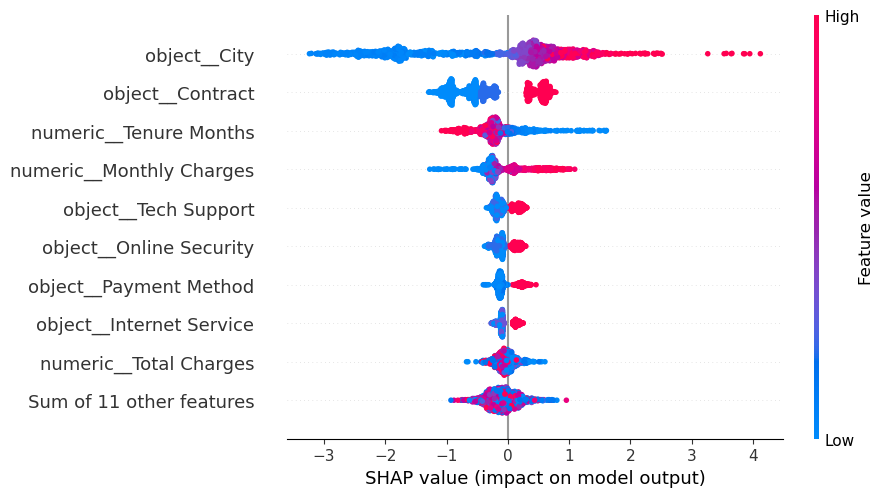

In [39]:
shap_values_s3_sub = {}
for m in trained_models_s3:
    shap_diagnostics(m.model, X_test_s3, shap_values_s3_sub)

# 3. Advanced Analytics

### 3.1 SHAP Stability Across Subpopulations - Using Jensen-Shannon Divergence

In [40]:
from scipy.spatial.distance import jensenshannon

def jsd_shap_feature(shap_values, mask_A, mask_B, feature_index, bins=50):
    shap_A = shap_values[mask_A, feature_index].values
    shap_B = shap_values[mask_B, feature_index].values

    # Convert to histograms (probability distributions)
    hist_A, bin_edges = np.histogram(shap_A, bins=bins, density=True)
    hist_B, _ = np.histogram(shap_B, bins=bin_edges, density=True)

    # Add small epsilon to avoid log(0)
    eps = 1e-10
    hist_A += eps
    hist_B += eps

    # Normalize
    hist_A /= hist_A.sum()
    hist_B /= hist_B.sum()

    return jensenshannon(hist_A, hist_B)

In [67]:
def jsd_all_features(shap_values, mask_A, mask_B, feature_names):
    jsd_scores = {}

    for i, feature in enumerate(feature_names):
        jsd = jsd_shap_feature(shap_values, mask_A, mask_B, i)
        jsd_scores[feature] = jsd

    return jsd_scores

In [42]:
# Visualization
import pandas as pd
def visualize_jsd_scores(jsd_scores, group='Tenure'):
    jsd_df = pd.DataFrame.from_dict(jsd_scores, orient="index", columns=["JSD"])
    jsd_df = jsd_df.sort_values("JSD", ascending=False)

    plt.figure(figsize=(10, 6))
    plt.barh(jsd_df.index, jsd_df["JSD"])
    plt.xlabel("Jensen-Shannon Divergence")
    plt.title(f"SHAP Distribution Shift Across {group} Groups")
    plt.gca().invert_yaxis()
    plt.show()

In [43]:
# Visualization - heatmap
import seaborn as sns
def visualize_jsd_scores_heatmap(jsd_scores, group='Tenure'):
    jsd_df = pd.DataFrame(list(jsd_scores.items()), columns=['Feature', 'JSD'])

    # Reshape for heatmap (single column)
    jsd_heatmap = jsd_df.set_index('Feature')[['JSD']]

    plt.figure(figsize=(10, 6))
    sns.heatmap(jsd_heatmap, annot=True, fmt='.3f', cmap='YlOrRd', cbar_kws={'label': 'JSD Score'})
    plt.xlabel("Jensen-Shannon Divergence")
    plt.title(f"SHAP Distribution Shift Across {group} Groups")
    plt.gca().invert_yaxis()
    plt.show()

In [44]:
# splitting data

X_train, X_test, y_train, y_test, mask_dict = preprocess_data_shap_stability_analysis(df, X, y)

Mask 'X_mask_early_to_medium': 1415 samples
Mask 'X_mask_medium_to_large': 1252 samples
Mask 'X_mask_city_top3': 145 samples
Mask 'X_mask_city_above_top15': 1442 samples
Mask 'Signle_without_children': 824 samples
Mask 'Signle_with_children': 68 samples
Mask 'Families_with_children': 340 samples


In [45]:
# training models

trained_models = train_model(model_list, X_train, X_test, y_train, y_test, 'SHAP Stability')


Testing DecisionTree/RF on SHAP Stability:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.84      0.79      0.81      1294
           1       0.50      0.59      0.54       467

    accuracy                           0.74      1761
   macro avg       0.67      0.69      0.68      1761
weighted avg       0.75      0.74      0.74      1761


Testing XGBoost on SHAP Stability:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.83      0.76      0.80      1294
           1       0.46      0.57      0.51       467

    accuracy                           0.71      1761
   macro avg       0.65      0.67      0.65      1761
weighted avg       0.73      0.71      0.72      1761

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1402, number of negative: 3880
[LightGBM] [Info] Auto-choosing row-wise multi-threadin

RandomForestClassifier


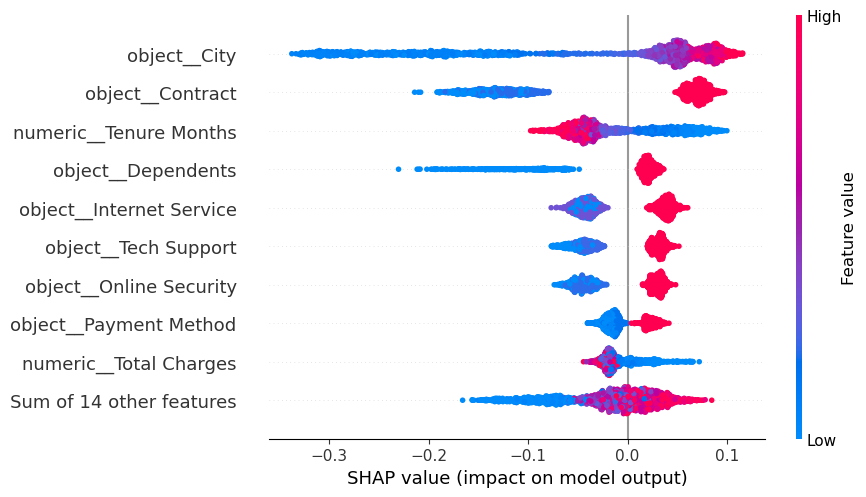

XGBClassifier


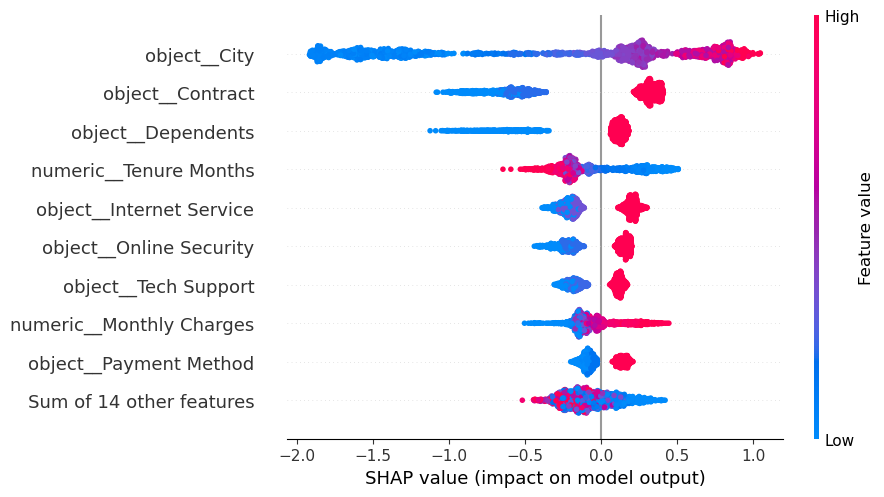

LGBMClassifier


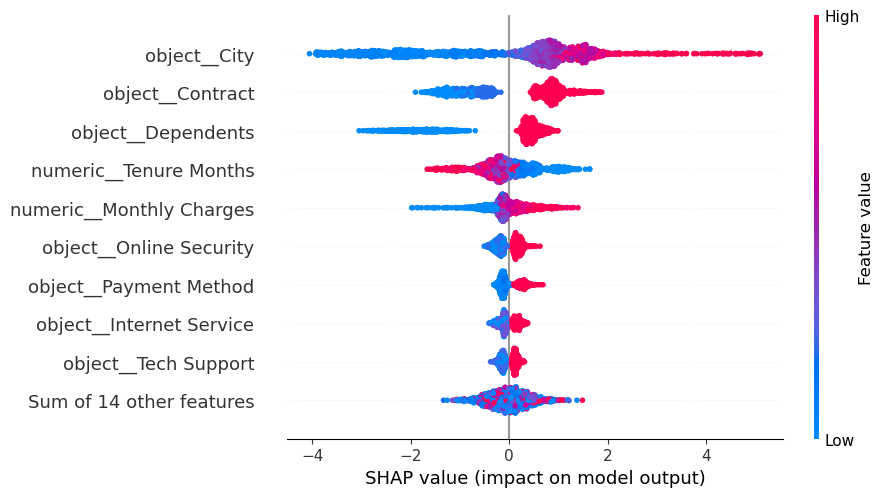

GradientBoostingClassifier


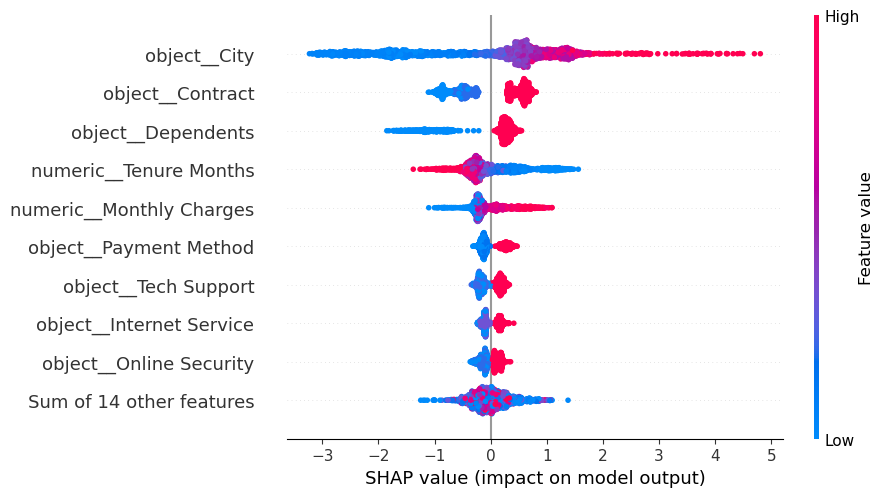

In [46]:
shap_scores_general = {}
for m in trained_models:
    shap_diagnostics(m.model, X_test, shap_scores_general)

3.1.1 Tenure Cohort

In [47]:
jsd_scores_tenure_dict = {}
for model_name in shap_scores_general.keys():
    jsd_scores_tenure = jsd_all_features(shap_scores_general[model_name], mask_dict['X_mask_early_to_medium'], 
                            mask_dict['X_mask_medium_to_large'], X_test.columns)
    jsd_scores_tenure_dict[model_name] = dict(sorted(jsd_scores_tenure.items(), key=lambda x: x[1], reverse=True))

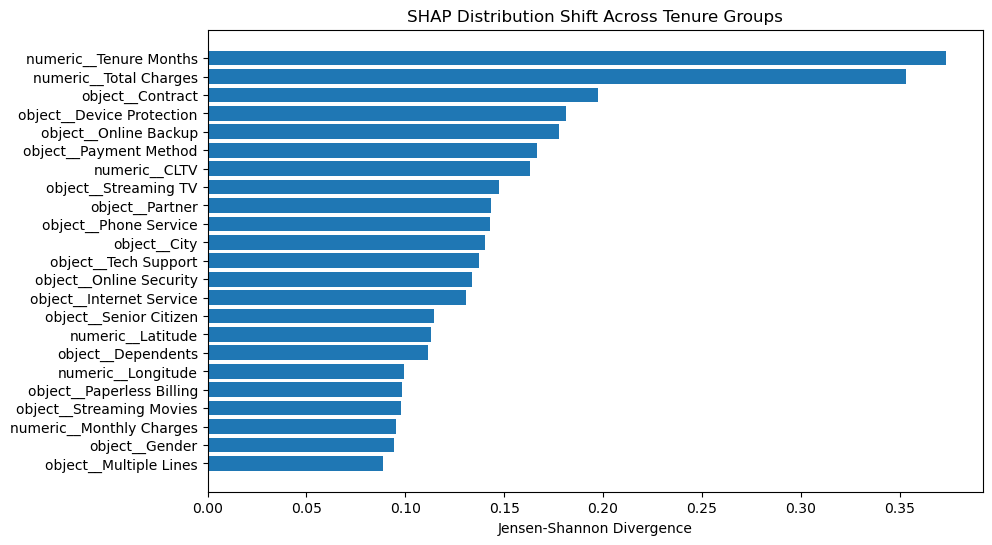

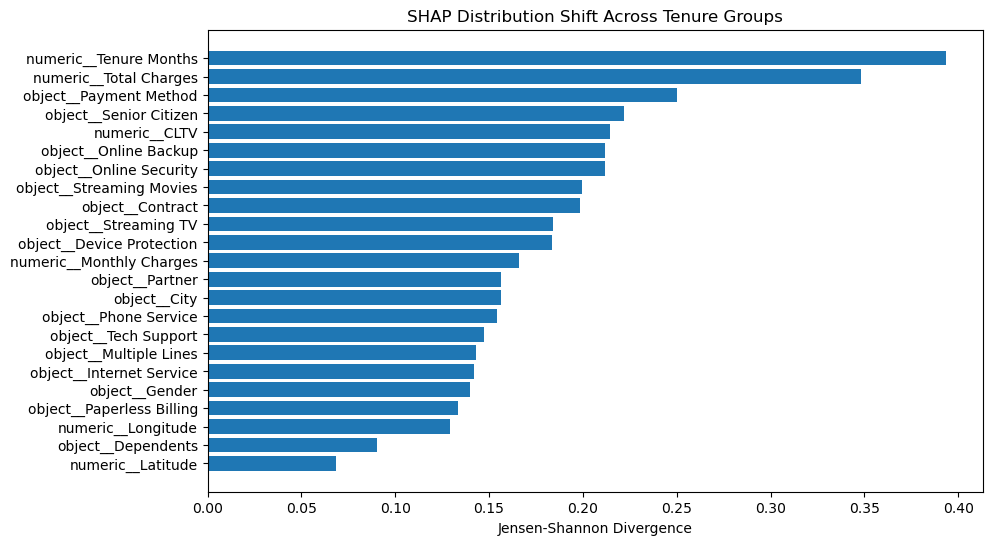

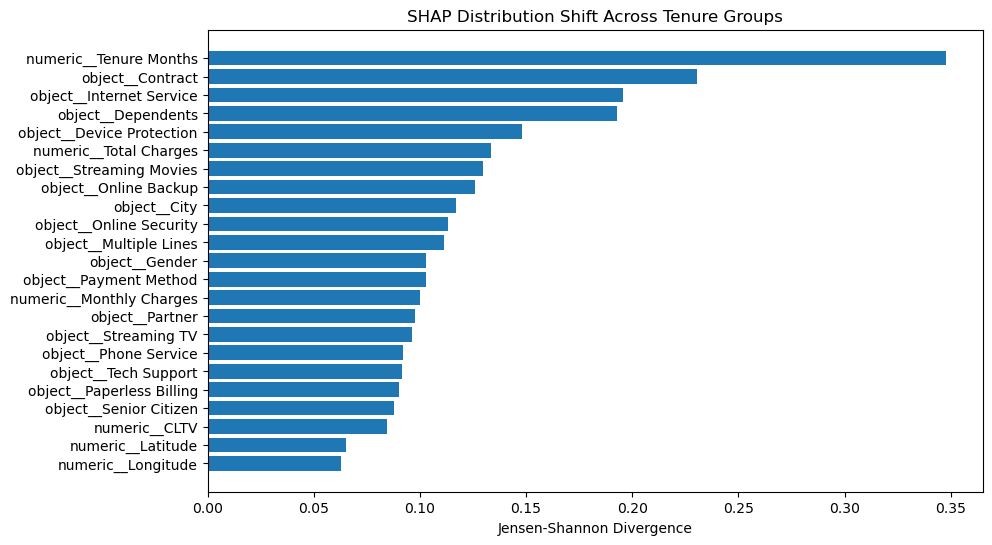

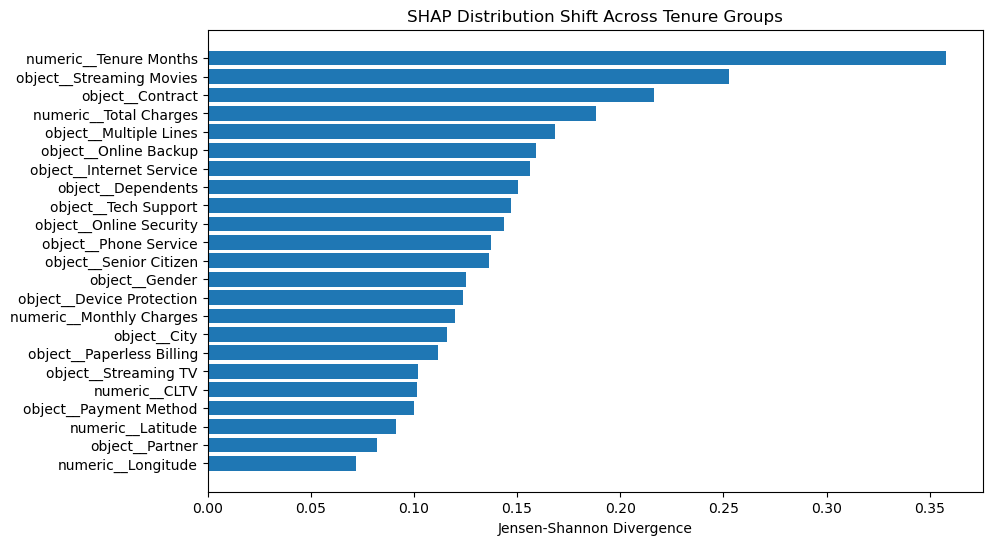

In [48]:
for key in jsd_scores_tenure_dict.keys():
    visualize_jsd_scores(jsd_scores_tenure_dict[key])

3.1.2 City

In [49]:
jsd_scores_city_dict = {}
for model_name in shap_scores_general.keys():
    jsd_scores_city = jsd_all_features(shap_scores_general[model_name], mask_dict['X_mask_city_top3'], 
                            mask_dict['X_mask_city_above_top15'], X_test.columns)
    jsd_scores_city_dict[model_name] = dict(sorted(jsd_scores_city.items(), key=lambda x: x[1], reverse=True))

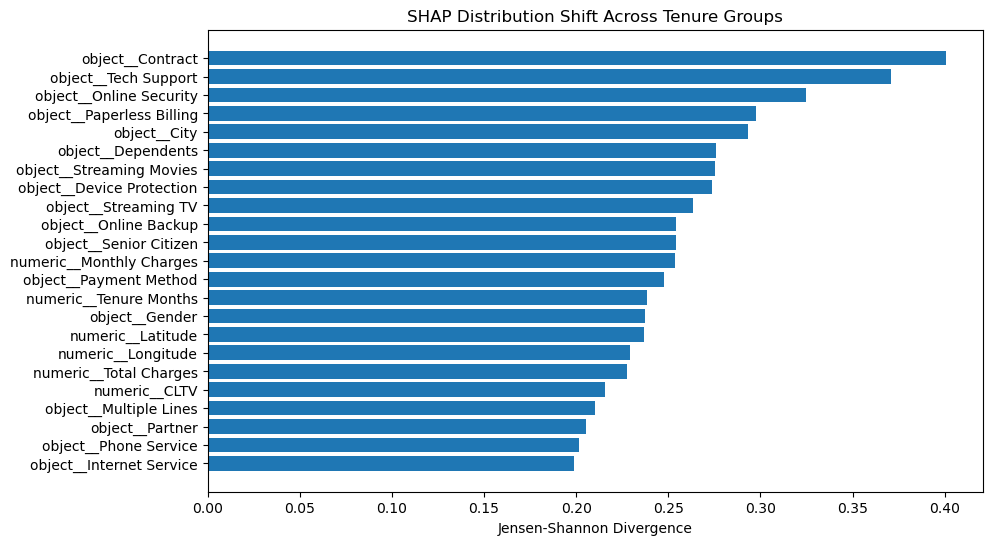

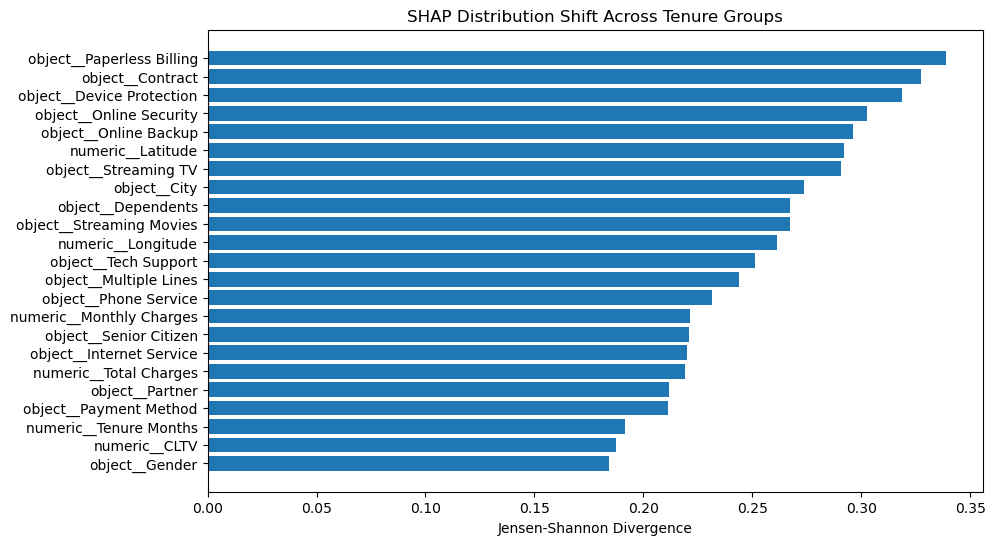

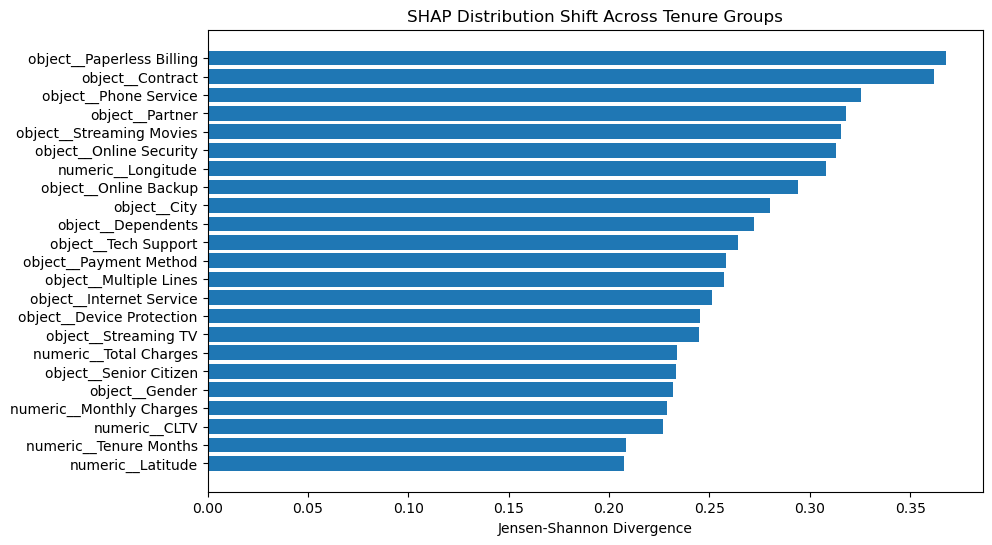

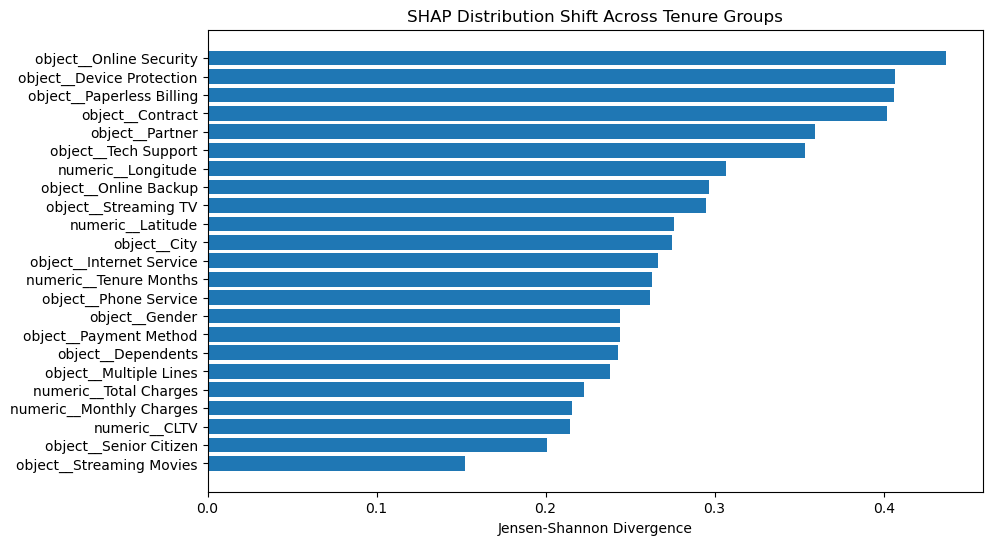

In [50]:
for key in jsd_scores_city_dict.keys():
    visualize_jsd_scores(jsd_scores_city_dict[key])

3.1.3 Family Status

In [69]:
jsd_scores_status_dict = {}
for model_name in shap_scores_general.keys():
    jsd_scores_status= jsd_all_features(shap_scores_general[model_name], mask_dict['Signle_without_children'], 
                            mask_dict['Signle_with_children'], X_test.columns)
    jsd_scores_status_dict[model_name] = dict(sorted(jsd_scores_status.items(), key=lambda x: x[1], reverse=True))

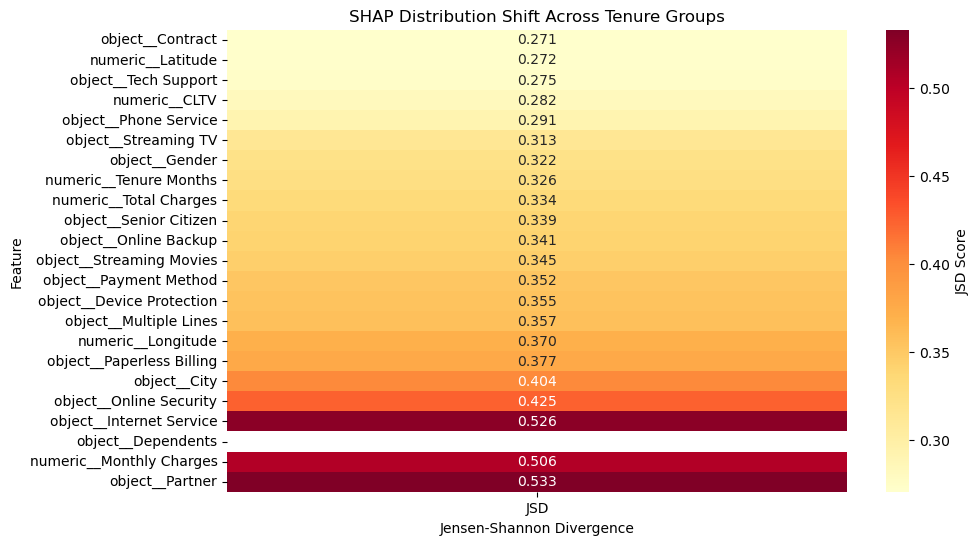

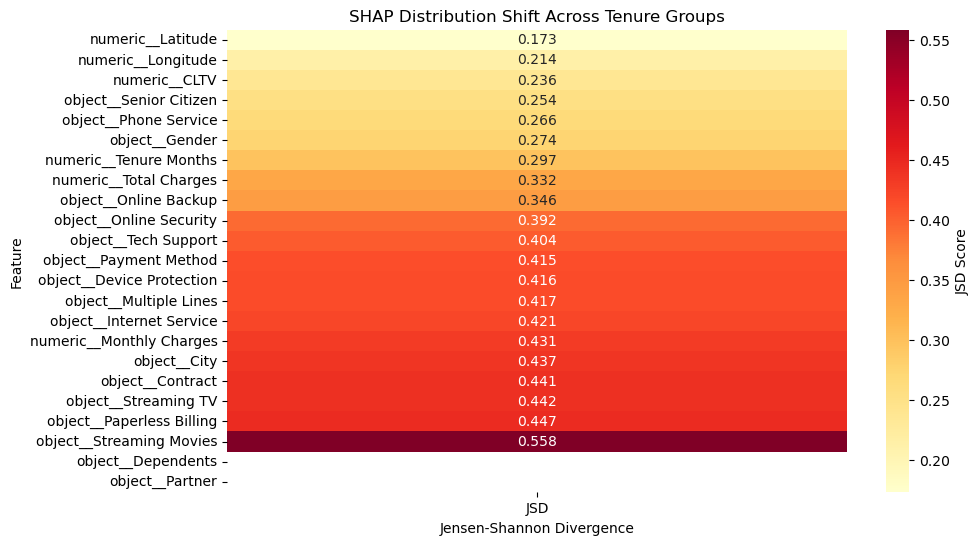

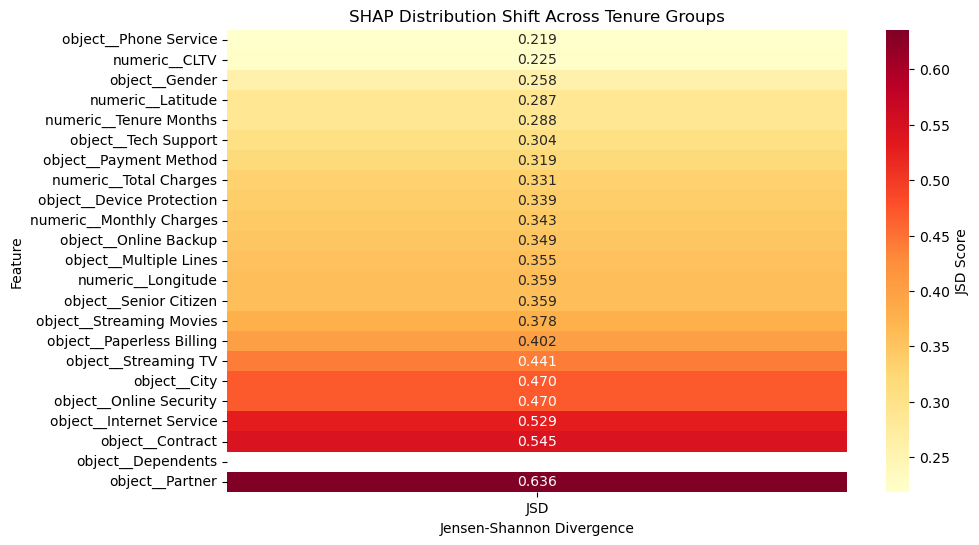

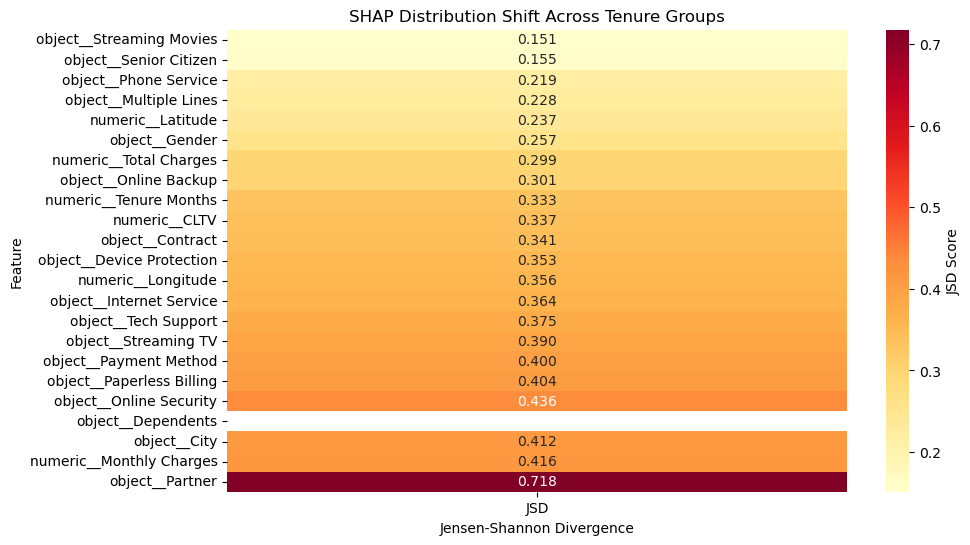

In [70]:
for key in jsd_scores_status_dict.keys():
    visualize_jsd_scores_heatmap(jsd_scores_status_dict[key])

### 3.2 Fairness / Bias Diagnostics